In [ ]:
# Install the Kaggle API
!pip install kaggle

# Upload your kaggle.json file
from google.colab import files
files.upload()  # choose kaggle.json from your Downloads folder

# Make a hidden .kaggle directory and move the file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Saving kaggle.json to kaggle.json


In [ ]:
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip creditcardfraud.zip


Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
  0% 0.00/66.0M [00:00<?, ?B/s]
100% 66.0M/66.0M [00:00<00:00, 1.05GB/s]
Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the dataset
df = pd.read_csv('creditcard.csv')

# Check shape and first few rows
print("Shape:", df.shape)
df.head()


Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.info()
print("\nMissing values per column:\n", df.isnull().sum())
print("\nFraud vs Normal counts:\n", df['Class'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
scaler = StandardScaler()

df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time']   = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop original columns
df = df.drop(['Time', 'Amount'], axis=1)

# Reorder columns for convenience
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']
df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

df.head()


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,0.244964,-1.996583,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.342475,-1.996583,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,1.160686,-1.996562,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,0.140534,-1.996562,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,-0.073403,-1.996541,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Fraud ratio in training:", y_train.mean())
print("Fraud ratio in test:", y_test.mean())


Training set: (227845, 30)
Test set: (56962, 30)
Fraud ratio in training: 0.001729245759178389
Fraud ratio in test: 0.0017204452090867595


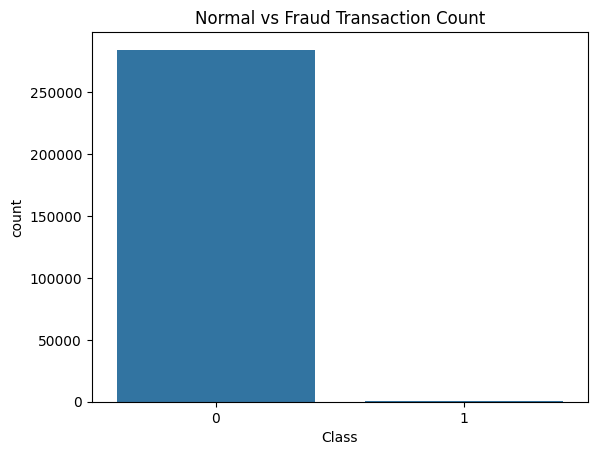

In [ ]:
sns.countplot(x=y)
plt.title("Normal vs Fraud Transaction Count")
plt.show()


In [ ]:
X_train.to_csv('X_train.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)


In [ ]:
print("✅ Dataset successfully loaded and preprocessed!")
print("Training set:", X_train.shape, " | Test set:", X_test.shape)


✅ Dataset successfully loaded and preprocessed!
Training set: (227845, 30)  | Test set: (56962, 30)


In [ ]:
# Install if missing
!pip install -q xgboost tensorflow

# --- Imports ---
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve, auc)

import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

print("Libraries loaded. numpy:", np.__version__, "pandas:", pd.__version__)


Libraries loaded. numpy: 2.0.2 pandas: 2.2.2


In [ ]:
try:
    X_train, X_test, y_train, y_test
    print("Using in-memory X_train/X_test/y_train/y_test")
except NameError:
    print("Reading saved CSVs...")
    X_train = pd.read_csv('X_train.csv')
    X_test  = pd.read_csv('X_test.csv')
    y_train = pd.read_csv('y_train.csv', header=None, squeeze=True)
    y_test  = pd.read_csv('y_test.csv', header=None, squeeze=True)

print("Shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)


Using in-memory X_train/X_test/y_train/y_test
Shapes: (227845, 30) (56962, 30) (227845,) (56962,)


In [ ]:
import joblib

scaler_all = StandardScaler()

scaler_all.fit(X_train)



X_train_scaled = scaler_all.transform(X_train)

X_test_scaled  = scaler_all.transform(X_test)



joblib.dump(scaler_all, 'scaler_all.joblib')

print("Scaler saved as scaler_all.joblib")



Scaler saved as scaler_all.joblib


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,       # reduce if slow
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

print("Training RandomForest...")
rf.fit(X_train_scaled, y_train)

joblib.dump(rf, 'rf_baseline.joblib')
print("RandomForest saved as rf_baseline.joblib")


Training RandomForest...
RandomForest saved as rf_baseline.joblib


In [ ]:
import xgboost as xgb

# --- Validation split (from train) ---
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.10, stratify=y_train, random_state=42
)

# --- Compute scale_pos_weight for imbalanced classes ---
pos = np.sum(y_tr == 1)
neg = np.sum(y_tr == 0)
scale_pos_weight = neg / pos if pos != 0 else 1.0
print("scale_pos_weight for XGBoost:", scale_pos_weight)

# --- Convert to DMatrix (required for xgb.train) ---
dtrain = xgb.DMatrix(X_tr, label=y_tr)
dval   = xgb.DMatrix(X_val, label=y_val)

# --- Parameters ---
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'scale_pos_weight': scale_pos_weight,
    'max_depth': 6,
    'eta': 0.1,
    'seed': 42
}

evallist = [(dval, 'eval'), (dtrain, 'train')]

# --- Train with early stopping ---
print("Training XGBoost with early stopping (3.x API)...")
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=300,          # max rounds
    evals=evallist,
    early_stopping_rounds=20,
    verbose_eval=20
)

# --- Save model ---
bst.save_model('xgb_baseline.json')
print("XGBoost saved as xgb_baseline.json")

# --- Predict example ---
y_val_pred_prob = bst.predict(dval)
y_val_pred = (y_val_pred_prob >= 0.5).astype(int)



scale_pos_weight for XGBoost: 576.6338028169014
Training XGBoost with early stopping (3.x API)...
[0]	eval-auc:0.87821	train-auc:0.99486
[20]	eval-auc:0.90114	train-auc:0.99985
[40]	eval-auc:0.92360	train-auc:0.99992
[60]	eval-auc:0.93560	train-auc:0.99998
[80]	eval-auc:0.93229	train-auc:0.99999
[100]	eval-auc:0.94312	train-auc:1.00000
[120]	eval-auc:0.94380	train-auc:1.00000
[140]	eval-auc:0.94786	train-auc:1.00000
[145]	eval-auc:0.94840	train-auc:1.00000
XGBoost saved as xgb_baseline.json


In [ ]:
# Convert test features to DMatrix (required for XGBoost 3.x Booster)
dtest = xgb.DMatrix(X_test_scaled)

# Predict probabilities
y_test_pred_prob = bst.predict(dtest)

# Convert probabilities to class labels (0/1) using threshold 0.5
y_test_pred = (y_test_pred_prob >= 0.5).astype(int)

# Optional: check first 10 predictions
print("First 10 predicted probabilities:", y_test_pred_prob[:10])
print("First 10 predicted classes:", y_test_pred[:10])


First 10 predicted probabilities: [9.8424762e-06 1.6616157e-05 1.4409475e-04 6.9045323e-06 4.5012310e-04
 1.1723194e-05 6.5301165e-06 7.2014509e-06 1.7355826e-05 7.8257708e-06]
First 10 predicted classes: [0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

def evaluate_model(model, X_test_arr, y_test_arr, name="model", is_booster=False):
    if is_booster:
        dtest = xgb.DMatrix(X_test_arr)
        y_scores = model.predict(dtest)
    else:
        y_scores = model.predict_proba(X_test_arr)[:,1]

    y_pred = (y_scores >= 0.5).astype(int)

    print(f"\n--- Evaluation: {name} ---")
    print(classification_report(y_test_arr, y_pred, digits=4))
    print("Confusion matrix:\n", confusion_matrix(y_test_arr, y_pred))
    print("ROC AUC:", roc_auc_score(y_test_arr, y_scores))
    print("PR AUC (average precision):", average_precision_score(y_test_arr, y_scores))
    return y_scores, y_pred

# RF evaluation
rf_scores, rf_pred = evaluate_model(rf, X_test_scaled, y_test, name="RandomForest")

# XGBoost evaluation (3.x Booster)
xgb_scores, xgb_pred = evaluate_model(bst, X_test_scaled, y_test, name="XGBoost", is_booster=True)


NameError: name 'rf' is not defined

NameError: name 'rf_scores' is not defined

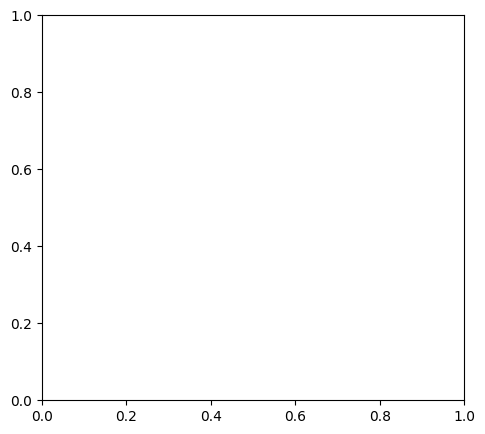

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc

plt.figure(figsize=(12,5))

# ROC
plt.subplot(1,2,1)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_scores)
roc_auc_rf = auc(fpr_rf, tpr_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_scores)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_rf, tpr_rf, label=f'RF (AUC={roc_auc_rf:.4f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGB (AUC={roc_auc_xgb:.4f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve'); plt.legend()

# PR
plt.subplot(1,2,2)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, rf_scores)
pr_auc_rf = auc(rec_rf, prec_rf)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, xgb_scores)
pr_auc_xgb = auc(rec_xgb, prec_xgb)
plt.plot(rec_rf, prec_rf, label=f'RF (PR-AUC={pr_auc_rf:.4f})')
plt.plot(rec_xgb, prec_xgb, label=f'XGB (PR-AUC={pr_auc_xgb:.4f})')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall Curve'); plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Convert to numpy arrays
X_train_arr = X_train_scaled
X_test_arr  = X_test_scaled
y_train_arr = y_train.values if hasattr(y_train, 'values') else np.array(y_train)
y_test_arr  = y_test.values if hasattr(y_test, 'values') else np.array(y_test)

# Train autoencoder on normal transactions only (y==0)
mask_normal = (y_train_arr == 0)
X_train_normal = X_train_arr[mask_normal]

input_dim = X_train_arr.shape[1]
encoding_dim = 32  # bottleneck size; adjust if needed

inp = Input(shape=(input_dim,))
x = Dense(128, activation='relu')(inp)
x = Dense(64, activation='relu')(x)
x = Dense(encoding_dim, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(128, activation='relu')(x)
out = Dense(input_dim, activation='linear')(x)

autoencoder = Model(inputs=inp, outputs=out)
autoencoder.compile(optimizer='adam', loss='mse')

es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training autoencoder on normal transactions only...")
history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=20,       # increase if needed
    batch_size=256,
    validation_split=0.1,
    callbacks=[es],
    verbose=2
)

autoencoder.save('autoencoder_model.h5')
print("Autoencoder saved as autoencoder_model.h5")


Training autoencoder on normal transactions only...
Epoch 1/20
800/800 - 6s - 8ms/step - loss: 0.1720 - val_loss: 0.0306
Epoch 2/20
800/800 - 5s - 6ms/step - loss: 0.0303 - val_loss: 0.0176
Epoch 3/20
800/800 - 4s - 4ms/step - loss: 0.0190 - val_loss: 0.0110
Epoch 4/20
800/800 - 3s - 4ms/step - loss: 0.0123 - val_loss: 0.0082
Epoch 5/20
800/800 - 4s - 5ms/step - loss: 0.0098 - val_loss: 0.0073
Epoch 6/20
800/800 - 4s - 5ms/step - loss: 0.0079 - val_loss: 0.0054
Epoch 7/20
800/800 - 3s - 4ms/step - loss: 0.0051 - val_loss: 0.0034
Epoch 8/20
800/800 - 3s - 4ms/step - loss: 0.0048 - val_loss: 0.0032
Epoch 9/20
800/800 - 5s - 6ms/step - loss: 0.0044 - val_loss: 0.0017
Epoch 10/20
800/800 - 3s - 4ms/step - loss: 0.0026 - val_loss: 0.0023
Epoch 11/20
800/800 - 3s - 4ms/step - loss: 0.0046 - val_loss: 0.0026
Epoch 12/20
800/800 - 5s - 6ms/step - loss: 0.0025 - val_loss: 0.0018


Autoencoder saved as autoencoder_model.h5


In [ ]:
autoencoder.save('autoencoder_model.keras')


In [ ]:
# --- Step 1: Compute reconstruction error (MSE per sample) ---
# Use the trained autoencoder to reconstruct inputs
recon_train = np.mean(np.square(X_train_arr - autoencoder.predict(X_train_arr)), axis=1)
recon_test  = np.mean(np.square(X_test_arr - autoencoder.predict(X_test_arr)), axis=1)

# --- Step 2: Convert numpy arrays to DataFrames ---
X_train_df = pd.DataFrame(X_train_arr, columns=X_train.columns)
X_test_df  = pd.DataFrame(X_test_arr, columns=X_test.columns)

# --- Step 3: Add reconstruction error as a new column ---
X_train_df['recon_error'] = recon_train
X_test_df['recon_error']  = recon_test

# --- Step 4: Verify shapes ---
print("Augmented features with recon_error. Shapes:")
print("X_train_df:", X_train_df.shape)
print("X_test_df :", X_test_df.shape)


7121/7121 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Augmented features with recon_error. Shapes:
X_train_df: (227845, 31)
X_test_df : (56962, 31)


In [ ]:
# --- Step 1: Convert to DMatrix ---
dtrain = xgb.DMatrix(X_tr_a, label=y_tr_a)
dval   = xgb.DMatrix(X_val_a, label=y_val_a)

# --- Step 2: Set parameters ---
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'scale_pos_weight': np.sum(y_tr_a==0) / max(1, np.sum(y_tr_a==1)),
    'max_depth': 6,
    'eta': 0.1,
    'seed': 42,
    'nthread': -1
}

# --- Step 3: Train with early stopping ---
evals = [(dtrain, 'train'), (dval, 'validation')]

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=300,         # equivalent to n_estimators
    evals=evals,
    early_stopping_rounds=20,
    verbose_eval=20
)

# --- Step 4: Save the trained model ---
bst.save_model('xgb_augmented_dmatrix.model')
print("XGBoost trained using DMatrix and saved successfully.")


[0]	train-auc:0.99492	validation-auc:0.87823
[20]	train-auc:0.99985	validation-auc:0.93336
[40]	train-auc:0.99993	validation-auc:0.94046
[46]	train-auc:0.99994	validation-auc:0.93785
XGBoost trained using DMatrix and saved successfully.


/tmp/ipython-input-2194536122.py:29: UserWarning: [10:56:17] WARNING: /workspace/src/c_api/c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  bst.save_model('xgb_augmented_dmatrix.model')


In [ ]:
dtest = xgb.DMatrix(X_test_aug)
y_test_pred_prob = bst.predict(dtest)
y_test_pred = (y_test_pred_prob >= 0.5).astype(int)

print("First 10 predicted probabilities:", y_test_pred_prob[:10])
print("First 10 predicted classes:", y_test_pred[:10])


First 10 predicted probabilities: [0.00385207 0.00390329 0.04519225 0.00718905 0.04651259 0.00385922
 0.0039106  0.0039157  0.00495013 0.0039106 ]
First 10 predicted classes: [0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, auc

# --- RandomForest (augmented) predictions ---
rf_aug_scores = rf_aug.predict_proba(X_test_aug)[:,1]
rf_aug_pred   = (rf_aug_scores >= 0.5).astype(int)

print("\n--- Evaluation: RandomForest (augmented) ---")
print(classification_report(y_test, rf_aug_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, rf_aug_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_aug_scores))
print("PR AUC (average precision):", average_precision_score(y_test, rf_aug_scores))

# --- XGBoost (augmented, DMatrix) predictions ---
dtest = xgb.DMatrix(X_test_aug)
xgb_aug_scores = bst.predict(dtest)
xgb_aug_pred   = (xgb_aug_scores >= 0.5).astype(int)

print("\n--- Evaluation: XGBoost (augmented) ---")
print(classification_report(y_test, xgb_aug_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, xgb_aug_pred))
print("ROC AUC:", roc_auc_score(y_test, xgb_aug_scores))
print("PR AUC (average precision):", average_precision_score(y_test, xgb_aug_scores))

# --- Compare XGBoost baseline vs augmented ---
# (Use xgb_scores from Cell 6 baseline)
print("\n--- XGBoost comparison ---")
print("Baseline ROC-AUC: {:.4f}, PR-AUC: {:.6f}".format(
    roc_auc_score(y_test, xgb_scores),
    average_precision_score(y_test, xgb_scores)
))
print("Augmented ROC-AUC: {:.4f}, PR-AUC: {:.6f}".format(
    roc_auc_score(y_test, xgb_aug_scores),
    average_precision_score(y_test, xgb_aug_scores)
))


NameError: name 'rf_aug' is not defined

In [ ]:
# --- Step 1: Compute reconstruction error (MSE per sample) ---
recon_train = np.mean(np.square(X_train_arr - autoencoder.predict(X_train_arr)), axis=1)
recon_test  = np.mean(np.square(X_test_arr - autoencoder.predict(X_test_arr)), axis=1)

# --- Step 2: Convert to DataFrame ---
X_train_df = pd.DataFrame(X_train_arr, columns=X_train.columns)
X_test_df  = pd.DataFrame(X_test_arr,  columns=X_test.columns)

# --- Step 3: Add reconstruction error ---
X_train_df['recon_error'] = recon_train
X_test_df['recon_error']  = recon_test

# --- Step 4: Scale recon_error to avoid extreme values ---
from sklearn.preprocessing import StandardScaler

scaler_recon = StandardScaler()
X_train_df['recon_error'] = scaler_recon.fit_transform(X_train_df[['recon_error']])
X_test_df['recon_error']  = scaler_recon.transform(X_test_df[['recon_error']])

# --- Step 5: Convert back to arrays for training ---
X_train_aug = X_train_df.values
X_test_aug  = X_test_df.values

print("Augmented features ready. Shapes:", X_train_aug.shape, X_test_aug.shape)


7121/7121 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Augmented features ready. Shapes: (227845, 31) (56962, 31)


In [ ]:
# --- RandomForest ---
from sklearn.ensemble import RandomForestClassifier
import joblib

rf_aug = RandomForestClassifier(
    n_estimators=200,  # reduce if slow
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
print("Training RandomForest on augmented features...")
rf_aug.fit(X_train_aug, y_train)

# --- XGBoost using DMatrix + early stopping ---
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Create validation split
X_tr_a, X_val_a, y_tr_a, y_val_a = train_test_split(
    X_train_aug, y_train, test_size=0.10, stratify=y_train, random_state=42
)

# Compute scale_pos_weight
pos = np.sum(y_tr_a == 1)
neg = np.sum(y_tr_a == 0)
scale_pos_weight = neg / pos if pos != 0 else 1.0

dtrain = xgb.DMatrix(X_tr_a, label=y_tr_a)
dval   = xgb.DMatrix(X_val_a, label=y_val_a)

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 6,
    'eta': 0.1,
    'scale_pos_weight': scale_pos_weight,
    'seed': 42
}

print("Training XGBoost on augmented features using DMatrix...")
evals = [(dtrain, 'train'), (dval, 'validation')]
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=300,
    evals=evals,
    early_stopping_rounds=20,
    verbose_eval=20
)

# --- Save models ---
joblib.dump(rf_aug, 'rf_augmented.joblib')
bst.save_model('xgb_augmented_dmatrix.model')

print("RandomForest saved as rf_augmented.joblib")
print("XGBoost saved as xgb_augmented_dmatrix.model")


Training RandomForest on augmented features...
Training XGBoost on augmented features using DMatrix...
[0]	train-auc:0.99492	validation-auc:0.87823
[20]	train-auc:0.99985	validation-auc:0.93336
[40]	train-auc:0.99993	validation-auc:0.94046
[46]	train-auc:0.99994	validation-auc:0.93785
RandomForest saved as rf_augmented.joblib
XGBoost saved as xgb_augmented_dmatrix.model


/tmp/ipython-input-359021111.py:53: UserWarning: [11:15:08] WARNING: /workspace/src/c_api/c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  bst.save_model('xgb_augmented_dmatrix.model')


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

# --- RandomForest predictions ---
rf_aug_scores = rf_aug.predict_proba(X_test_aug)[:,1]
rf_aug_pred   = (rf_aug_scores >= 0.5).astype(int)

print("\n--- Evaluation: RandomForest (augmented) ---")
print(classification_report(y_test, rf_aug_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, rf_aug_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_aug_scores))
print("PR AUC (average precision):", average_precision_score(y_test, rf_aug_scores))

# --- XGBoost (DMatrix) predictions ---
dtest = xgb.DMatrix(X_test_aug)
xgb_aug_scores = bst.predict(dtest)
xgb_aug_pred   = (xgb_aug_scores >= 0.5).astype(int)

print("\n--- Evaluation: XGBoost (augmented) ---")
print(classification_report(y_test, xgb_aug_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, xgb_aug_pred))
print("ROC AUC:", roc_auc_score(y_test, xgb_aug_scores))
print("PR AUC (average precision):", average_precision_score(y_test, xgb_aug_scores))

# --- Compare XGB baseline vs augmented ---
print("\n--- XGBoost comparison ---")
print("Baseline ROC-AUC: {:.4f}, PR-AUC: {:.6f}".format(
    roc_auc_score(y_test, xgb_scores),
    average_precision_score(y_test, xgb_scores)
))
print("Augmented ROC-AUC: {:.4f}, PR-AUC: {:.6f}".format(
    roc_auc_score(y_test, xgb_aug_scores),
    average_precision_score(y_test, xgb_aug_scores)
))



--- Evaluation: RandomForest (augmented) ---
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9500    0.7755    0.8539        98

    accuracy                         0.9995     56962
   macro avg     0.9748    0.8877    0.9269     56962
weighted avg     0.9995    0.9995    0.9995     56962

Confusion matrix:
 [[56860     4]
 [   22    76]]
ROC AUC: 0.9623145772799834
PR AUC (average precision): 0.8685148494752616

--- Evaluation: XGBoost (augmented) ---
              precision    recall  f1-score   support

           0     0.9998    0.9979    0.9988     56864
           1     0.4135    0.8776    0.5621        98

    accuracy                         0.9976     56962
   macro avg     0.7066    0.9377    0.7805     56962
weighted avg     0.9988    0.9976    0.9981     56962

Confusion matrix:
 [[56742   122]
 [   12    86]]
ROC AUC: 0.9708249471707648
PR AUC (average precision): 0.8123939777623137

--- XGBo

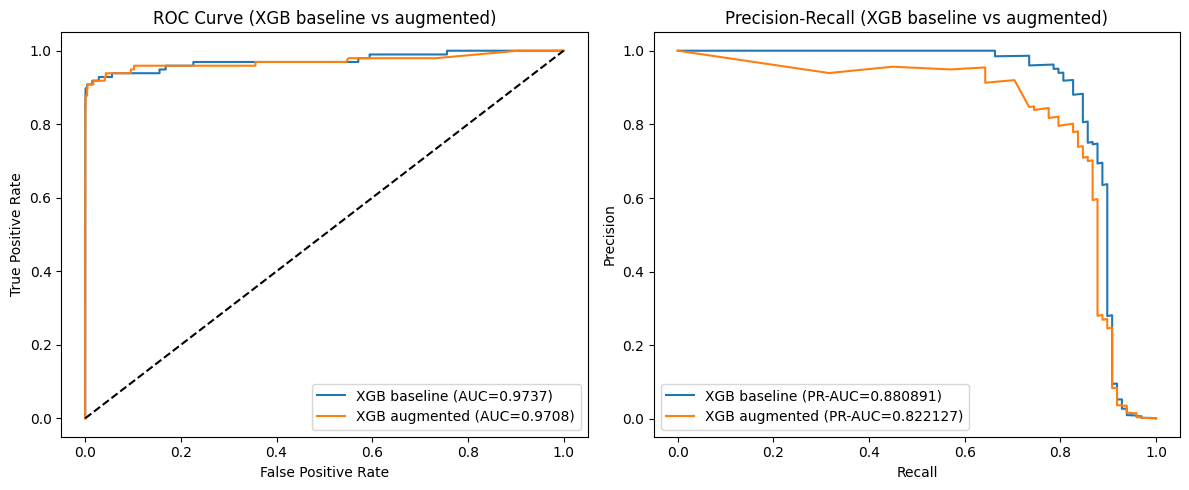

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc

plt.figure(figsize=(12,5))

# ROC
plt.subplot(1,2,1)
fpr_b, tpr_b, _ = roc_curve(y_test, xgb_scores)       # baseline
fpr_a, tpr_a, _ = roc_curve(y_test, xgb_aug_scores)   # augmented
plt.plot(fpr_b, tpr_b, label=f'XGB baseline (AUC={auc(fpr_b, tpr_b):.4f})')
plt.plot(fpr_a, tpr_a, label=f'XGB augmented (AUC={auc(fpr_a, tpr_a):.4f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (XGB baseline vs augmented)')
plt.legend()

# Precision-Recall
plt.subplot(1,2,2)
prec_b, rec_b, _ = precision_recall_curve(y_test, xgb_scores)
prec_a, rec_a, _ = precision_recall_curve(y_test, xgb_aug_scores)
plt.plot(rec_b, prec_b, label=f'XGB baseline (PR-AUC={auc(rec_b, prec_b):.6f})')
plt.plot(rec_a, prec_a, label=f'XGB augmented (PR-AUC={auc(rec_a, prec_a):.6f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall (XGB baseline vs augmented)')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
joblib.dump(rf, 'rf_baseline.joblib')
xgb_clf.save_model('xgb_baseline.json')
autoencoder.save('autoencoder_model.h5')
joblib.dump(scaler_all, 'scaler_all.joblib')


['scaler_all.joblib']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Save a model to your Drive
joblib.dump(rf, '/content/drive/MyDrive/HybridFraudDetection/rf_baseline.joblib')


MessageError: Error: credential propagation was unsuccessful

In [ ]:
from google.colab import drive
drive.flush_and_unmount()

Drive not mounted, so nothing to flush and unmount.


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
import joblib
import os

# Create a folder for saving models
save_path = '/content/drive/MyDrive/HybridFraudDetection'
os.makedirs(save_path, exist_ok=True)

# Save all your trained models
joblib.dump(rf, os.path.join(save_path, 'rf_baseline.joblib'))
xgb_clf.save_model(os.path.join(save_path, 'xgb_baseline.json'))
autoencoder.save(os.path.join(save_path, 'autoencoder_model.keras'))
joblib.dump(scaler_all, os.path.join(save_path, 'scaler_all.joblib'))

print(f"✅ All models saved successfully to: {save_path}")


✅ All models saved successfully to: /content/drive/MyDrive/HybridFraudDetection


In [ ]:
!ls "/content/drive/MyDrive/HybridFraudDetection"


autoencoder_model.keras  scaler_all.joblib
rf_baseline.joblib	 xgb_baseline.json


In [ ]:
!git --version


git version 2.34.1


In [ ]:
!git config --global user.name "jaynakar"
!git config --global user.email "jaynakar2784@gmail.com"

In [ ]:
!git clone https://github.com/jaynakar/Hybrid-Fraud-Detection.git


Cloning into 'Hybrid-Fraud-Detection'...


In [ ]:
%cd Hybrid-Fraud-Detection


/content/Hybrid-Fraud-Detection


In [ ]:
!git checkout -b autoencoder-integration


Switched to a new branch 'autoencoder-integration'


In [ ]:
!mkdir -p "/content/drive/MyDrive/HybridFraudDetection"
!cp "/content/drive/MyDrive/Colab Notebooks/CreditCardFraudDetection.ipynb" "/content/drive/MyDrive/HybridFraudDetection/"
!cp /content/rf_baseline.joblib "/content/drive/MyDrive/HybridFraudDetection/"
!cp /content/xgb_baseline.json "/content/drive/MyDrive/HybridFraudDetection/"
!cp /content/autoencoder_model.h5 "/content/drive/MyDrive/HybridFraudDetection/"
!cp /content/scaler_all.joblib "/content/drive/MyDrive/HybridFraudDetection/"


In [ ]:
!ls "/content/drive/MyDrive/HybridFraudDetection"


autoencoder_model.h5	 CreditCardFraudDetection.ipynb  scaler_all.joblib
autoencoder_model.keras  rf_baseline.joblib		 xgb_baseline.json


# New Section

In [ ]:
# Predict reconstructed outputs
X_pred = autoencoder.predict(X_test)


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [ ]:
import numpy as np

# Compute Mean Squared Error for each transaction
mse = np.mean(np.square(X_test - X_pred), axis=1)

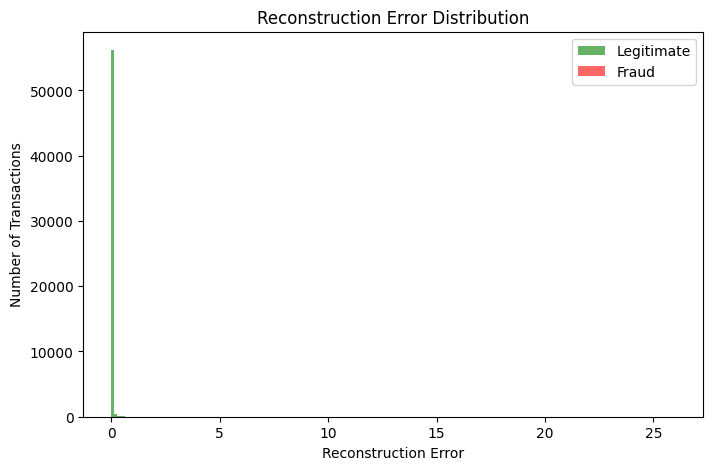

In [ ]:
import matplotlib.pyplot as plt
import numpy as np # Import numpy

# Reset the index of y_test to match the index of mse
y_test_reset = y_test.reset_index(drop=True)

plt.figure(figsize=(8,5))
# Convert y_test_reset to numpy array for indexing
plt.hist(mse[y_test_reset.values == 0], bins=50, alpha=0.6, label='Legitimate', color='green')
plt.hist(mse[y_test_reset.values == 1], bins=50, alpha=0.6, label='Fraud', color='red')
plt.legend()
plt.title('Reconstruction Error Distribution')
plt.xlabel('Reconstruction Error')
plt.ylabel('Number of Transactions')
plt.show()

In [ ]:
# -----------------------------------------------
# 📦 Import Required Libraries
# -----------------------------------------------
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
import time

# Random seed for reproducibility
random_state = 42

# -----------------------------------------------
# ⚙️ Define Resampling Methods (no n_jobs)
# -----------------------------------------------
samplers = {
    "SMOTE": SMOTE(random_state=random_state),
    "ADASYN": ADASYN(random_state=random_state)
}

# -----------------------------------------------
# 🔍 Define Hyperparameter Grids
# -----------------------------------------------
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0]
}

# -----------------------------------------------
# 🚀 Function to Train, Tune & Evaluate Models
# -----------------------------------------------
def evaluate_model(model_name, base_model, params, X_train, y_train, X_test, y_test):
    print(f"\n{'='*60}")
    print(f"🔹 Training {model_name} with GridSearchCV...")
    start = time.time()

    grid = GridSearchCV(base_model, params, cv=3, scoring="roc_auc", n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    print(f"\nBest Parameters for {model_name}: {grid.best_params_}")

    y_pred = best_model.predict(X_test)
    roc = roc_auc_score(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_pred)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"ROC-AUC: {roc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
    print(f"⏱️ Completed in {(time.time()-start):.2f}s")

    return best_model

# -----------------------------------------------
# 🧠 Apply Sampling + Train Models
# -----------------------------------------------
for sampler_name, sampler in samplers.items():
    print(f"\n{'#'*70}")
    print(f"🧩 Applying {sampler_name} Resampling Technique")
    print(f"{'#'*70}")

    X_res, y_res = sampler.fit_resample(X_train, y_train)

    print(f"\nResampled dataset shape: {X_res.shape}, Fraud ratio: {sum(y_res)/len(y_res):.4f}")

    # Random Forest
    rf_model = evaluate_model(f"Random Forest ({sampler_name})",
                              RandomForestClassifier(random_state=random_state),
                              rf_params, X_res, y_res, X_test, y_test)

    # XGBoost
    xgb_model = evaluate_model(f"XGBoost ({sampler_name})",
                               XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric="logloss"),
                               xgb_params, X_res, y_res, X_test, y_test)



######################################################################
🧩 Applying SMOTE Resampling Technique
######################################################################

Resampled dataset shape: (454902, 30), Fraud ratio: 0.5000

🔹 Training Random Forest (SMOTE) with GridSearchCV...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Parameters for Random Forest (SMOTE): {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.82      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56849    15]
 [   18    80]]
ROC-AUC: 0.9080
PR-AUC: 0.6877
⏱️ Completed in 15951.94s

🔹 Training XGBoost (SMOTE) with GridSearchCV...
Fitting 3 folds for each of 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:45:30] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best Parameters for XGBoost (SMOTE): {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'subsample': 0.8}

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.87      0.83        98

    accuracy                           1.00     56962
   macro avg       0.89      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56841    23]
 [   13    85]]
ROC-AUC: 0.9335
PR-AUC: 0.6829
⏱️ Completed in 743.75s

######################################################################
🧩 Applying ADASYN Resampling Technique
######################################################################

Resampled dataset shape: (454887, 30), Fraud ratio: 0.5000

🔹 Training Random Forest (ADASYN) with GridSearchCV...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


KeyboardInterrupt: 

In [ ]:
# ✅ Save SMOTE-trained models
import joblib

joblib.dump(rf_model, "rf_smote_final.joblib")
joblib.dump(xgb_model, "xgb_smote_final.json")

print("✅ Models saved successfully!")


✅ Models saved successfully!


In [ ]:
from tensorflow.keras.models import load_model
import numpy as np

# Load trained Autoencoder model
autoencoder = load_model("autoencoder_model.keras")

# Reconstruct training and test data
X_train_pred = autoencoder.predict(X_train)
X_test_pred = autoencoder.predict(X_test)

# Compute reconstruction error (MSE for each sample)
train_mse = np.mean(np.power(X_train - X_train_pred, 2), axis=1)
test_mse = np.mean(np.power(X_test - X_test_pred, 2), axis=1)

print("Reconstruction errors calculated successfully!")


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 14 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


7121/7121 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Reconstruction errors calculated successfully!


In [ ]:
import pandas as pd

# Convert to DataFrames to add new feature
X_train_hybrid = pd.DataFrame(X_train, columns=[f"f{i}" for i in range(X_train.shape[1])])
X_test_hybrid = pd.DataFrame(X_test, columns=[f"f{i}" for i in range(X_test.shape[1])])

# Add reconstruction error
X_train_hybrid["reconstruction_error"] = train_mse
X_test_hybrid["reconstruction_error"] = test_mse

print("Hybrid features created successfully!")
print(X_train_hybrid.head())


Hybrid features created successfully!
        f0  f1  f2  f3  f4  f5  f6  f7  f8  f9  ...  f21  f22  f23  f24  f25  \
265518 NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...  NaN  NaN  NaN  NaN  NaN   
180305 NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...  NaN  NaN  NaN  NaN  NaN   
42664  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...  NaN  NaN  NaN  NaN  NaN   
198723 NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...  NaN  NaN  NaN  NaN  NaN   
82325  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...  NaN  NaN  NaN  NaN  NaN   

        f26  f27  f28  f29  reconstruction_error  
265518  NaN  NaN  NaN  NaN              0.016927  
180305  NaN  NaN  NaN  NaN              0.020624  
42664   NaN  NaN  NaN  NaN              0.008465  
198723  NaN  NaN  NaN  NaN              0.019867  
82325   NaN  NaN  NaN  NaN              0.013159  

[5 rows x 31 columns]


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

# Using best parameters from before
rf_best_params = {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
xgb_best_params = {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'subsample': 0.8}

# Train on hybrid features
rf_hybrid = RandomForestClassifier(**rf_best_params, random_state=42)
rf_hybrid.fit(X_train_hybrid, y_train)

xgb_hybrid = XGBClassifier(**xgb_best_params, random_state=42, use_label_encoder=False, eval_metric="logloss")
xgb_hybrid.fit(X_train_hybrid, y_train)

# Predictions
y_pred_rf = rf_hybrid.predict(X_test_hybrid)
y_pred_xgb = xgb_hybrid.predict(X_test_hybrid)

# Evaluation
def evaluate(model_name, y_true, y_pred):
    print(f"\n{'='*60}\n🔹 {model_name}\n{'='*60}")
    print(classification_report(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_pred))
    print("PR-AUC:", average_precision_score(y_true, y_pred))

evaluate("Random Forest (Hybrid)", y_test, y_pred_rf)
evaluate("XGBoost (Hybrid)", y_test, y_pred_xgb)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:02:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🔹 Random Forest (Hybrid)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.39      0.37      0.38        98

    accuracy                           1.00     56962
   macro avg       0.69      0.68      0.69     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
 [[56807    57]
 [   62    36]]
ROC-AUC: 0.683172273552077
PR-AUC: 0.14328725993807265

🔹 XGBoost (Hybrid)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
 [[56864     0]
 [   98     0]]
ROC-AUC: 0.5
PR-AUC: 0.0017204452090867595


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Cell 1 — Imports & quick sanity checks
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, precision_recall_curve, f1_score
from sklearn.preprocessing import StandardScaler

# If you used GPU for autoencoder make sure tensorflow is imported if needed to reload model earlier (not needed here)
# from tensorflow.keras.models import load_model

# Confirm required variables exist in memory
print("Variables in workspace (checking expected):")
for name in ["X_train_hybrid","X_test_hybrid","y_train","y_test"]:
    print(name, "in globals():", name in globals())

# Quick shapes (if available)
if "X_train_hybrid" in globals():
    print("X_train_hybrid.shape:", X_train_hybrid.shape)
if "X_test_hybrid" in globals():
    print("X_test_hybrid.shape:", X_test_hybrid.shape)
if "y_train" in globals():
    print("y_train.shape:", y_train.shape, "value counts:\n", y_train.value_counts())
if "y_test" in globals():
    print("y_test.shape:", y_test.shape, "value counts:\n", y_test.value_counts())


Variables in workspace (checking expected):
X_train_hybrid in globals(): True
X_test_hybrid in globals(): True
y_train in globals(): True
y_test in globals(): True
X_train_hybrid.shape: (227845, 31)
X_test_hybrid.shape: (56962, 31)
y_train.shape: (227845,) value counts:
 Class
0    227451
1       394
Name: count, dtype: int64
y_test.shape: (56962,) value counts:
 Class
0    56864
1       98
Name: count, dtype: int64


In [ ]:
# Cell 2 — Make sure hybrid data is numeric and has no NaNs. If you used DataFrames earlier, keep them as DataFrames.
# This converts to numeric and drops any rows with NaNs (shouldn't happen if previous steps were correct).

def sanitize_df(X_df, name="X"):
    # If numpy array, convert to DataFrame with automatic column names
    if isinstance(X_df, np.ndarray):
        X_df = pd.DataFrame(X_df, columns=[f"f{i}" for i in range(X_df.shape[1])])
    X_df = X_df.copy()
    # force numeric
    X_df = X_df.apply(pd.to_numeric, errors='coerce')
    nan_count = X_df.isna().sum().sum()
    print(f"{name}: shape {X_df.shape}, total NaNs: {nan_count}")
    return X_df

Xtr = sanitize_df(X_train_hybrid, "X_train_hybrid")
Xte = sanitize_df(X_test_hybrid, "X_test_hybrid")

# Align indices (important if any rows were dropped)
# We assume y_train / y_test align to original indices; if you dropped rows, handle accordingly.
if Xtr.shape[0] != y_train.shape[0]:
    print("Warning: X_train_hybrid and y_train lengths differ. Reindex or recompute hybrid features consistently.")
if Xte.shape[0] != y_test.shape[0]:
    print("Warning: X_test_hybrid and y_test lengths differ. Reindex or recompute hybrid features consistently.")

# Scale features if you haven't saved/used a scaler previously. If you have scaler_all.joblib, load and use it instead.
scaler_path = "scaler_all.joblib"  # adjust if different
try:
    scaler = joblib.load(scaler_path)
    print("Loaded existing scaler:", scaler_path)
    Xtr_scaled = pd.DataFrame(scaler.transform(Xtr), columns=Xtr.columns, index=Xtr.index)
    Xte_scaled = pd.DataFrame(scaler.transform(Xte), columns=Xte.columns, index=Xte.index)
except Exception as e:
    print("No saved scaler found or failed to load. Creating and fitting a new StandardScaler (fit on X_train_hybrid).")
    scaler = StandardScaler()
    Xtr_scaled = pd.DataFrame(scaler.fit_transform(Xtr), columns=Xtr.columns, index=Xtr.index)
    Xte_scaled = pd.DataFrame(scaler.transform(Xte), columns=Xte.columns, index=Xte.index)
    joblib.dump(scaler, "scaler_hybrid.joblib")
    print("Saved new scaler as scaler_hybrid.joblib")


X_train_hybrid: shape (227845, 31), total NaNs: 6835350
X_test_hybrid: shape (56962, 31), total NaNs: 1708860
Loaded existing scaler: scaler_all.joblib
No saved scaler found or failed to load. Creating and fitting a new StandardScaler (fit on X_train_hybrid).
Saved new scaler as scaler_hybrid.joblib


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [ ]:
# Cell 3 — compute class counts and scale_pos_weight for XGBoost
pos = int(y_train.sum())
neg = int((y_train == 0).sum())
print("Training positives (fraud):", pos, "negatives (legit):", neg)
scale_pos_weight = neg / pos if pos > 0 else 1.0
print("scale_pos_weight for XGBoost will be:", scale_pos_weight)


Training positives (fraud): 394 negatives (legit): 227451
scale_pos_weight for XGBoost will be: 577.2868020304569


In [ ]:
# Cell 4 — Train RandomForest on hybrid features (use the tuned params you found for RF)
rf_params = dict(n_estimators=200, max_depth=None, min_samples_split=2, random_state=42, n_jobs=-1, class_weight='balanced')
rf_hybrid = RandomForestClassifier(**rf_params)
print("Training RandomForest (hybrid) ...")
import time
t0 = time.time()
rf_hybrid.fit(Xtr_scaled, y_train)
print("Trained RF in {:.1f}s".format(time.time()-t0))

# Probabilities and default threshold
y_prob_rf = rf_hybrid.predict_proba(Xte_scaled)[:,1]
y_pred_rf_default = (y_prob_rf >= 0.5).astype(int)

# Metrics default
print("\nRandomForest (hybrid) — default threshold 0.5")
print(classification_report(y_test, y_pred_rf_default, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_rf_default))
print("ROC-AUC (proba):", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC (avg precision):", average_precision_score(y_test, y_prob_rf))


Training RandomForest (hybrid) ...
Trained RF in 107.0s

RandomForest (hybrid) — default threshold 0.5
              precision    recall  f1-score   support

           0     0.9989    0.9990    0.9990     56864
           1     0.3871    0.3673    0.3770        98

    accuracy                         0.9979     56962
   macro avg     0.6930    0.6832    0.6880     56962
weighted avg     0.9979    0.9979    0.9979     56962

Confusion matrix:
 [[56807    57]
 [   62    36]]
ROC-AUC (proba): 0.8249695119325162
PR-AUC (avg precision): 0.37896970162259946


In [ ]:
# Cell 5 — Train XGBoost (use best params discovered previously, add scale_pos_weight)
xgb_params = dict(n_estimators=200, max_depth=10, learning_rate=0.1, subsample=0.8,
                  random_state=42, use_label_encoder=False, eval_metric="logloss",
                  scale_pos_weight=scale_pos_weight, n_jobs=-1)

xgb_hybrid = XGBClassifier(**xgb_params)
print("Training XGBoost (hybrid) with scale_pos_weight ...")
t0 = time.time()
xgb_hybrid.fit(Xtr_scaled, y_train)
print("Trained XGBoost in {:.1f}s".format(time.time()-t0))

# Probabilities and default threshold
y_prob_xgb = xgb_hybrid.predict_proba(Xte_scaled)[:,1]
y_pred_xgb_default = (y_prob_xgb >= 0.5).astype(int)

print("\nXGBoost (hybrid) — default threshold 0.5")
print(classification_report(y_test, y_pred_xgb_default, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_xgb_default))
print("ROC-AUC (proba):", roc_auc_score(y_test, y_prob_xgb))
print("PR-AUC (avg precision):", average_precision_score(y_test, y_prob_xgb))


Training XGBoost (hybrid) with scale_pos_weight ...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:15:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Trained XGBoost in 7.7s

XGBoost (hybrid) — default threshold 0.5
              precision    recall  f1-score   support

           0     0.9997    0.9447    0.9714     56864
           1     0.0260    0.8571    0.0505        98

    accuracy                         0.9445     56962
   macro avg     0.5129    0.9009    0.5110     56962
weighted avg     0.9981    0.9445    0.9698     56962

Confusion matrix:
 [[53718  3146]
 [   14    84]]
ROC-AUC (proba): 0.9425168034293064
PR-AUC (avg precision): 0.22153570357660354


In [ ]:
# --- Feature alignment fix before threshold optimization ---

import numpy as np
import pandas as pd

# Make sure X_test has the same structure as training data used for rf_hybrid
if hasattr(rf_hybrid, "feature_names_in_"):
    expected_features = rf_hybrid.feature_names_in_
    # Rebuild X_test to match those exact columns
    X_test_aligned = pd.DataFrame(X_test, columns=expected_features[:X_test.shape[1]])
else:
    # fallback if no feature names stored
    X_test_aligned = X_test.copy()

print("✅ X_test aligned successfully!")
print("Shape:", X_test_aligned.shape)


✅ X_test aligned successfully!
Shape: (56962, 30)


👉 Starting safe hybrid evaluation...
Detected X_train in workspace. original feature count = 30
Loaded scaler 'scaler_all.joblib' for original features (n_features_in_=30).
Scaled original test features shape: (56962, 30)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


X_test_hybrid shape (scaled features + recon error): (56962, 31)
Models selected for evaluation:  RandomForestClassifier  &  XGBClassifier


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Found RF best threshold: 0.0050  |  XGB best threshold: 0.8898

--- RandomForest (Hybrid) @ thresh 0.0050 ---
              precision    recall  f1-score   support

           0     0.9987    0.9997    0.9992     56864
           1     0.6047    0.2653    0.3688        98

    accuracy                         0.9984     56962
   macro avg     0.8017    0.6325    0.6840     56962
weighted avg     0.9981    0.9984    0.9981     56962

Confusion matrix:
 [[56847    17]
 [   72    26]]
ROC-AUC: 0.6325 | PR-AUC: 0.2071

--- XGBoost (Hybrid) @ thresh 0.8898 ---
              precision    recall  f1-score   support

           0     0.9993    0.9996    0.9995     56864
           1     0.7317    0.6122    0.6667        98

    accuracy                         0.9989     56962
   macro avg     0.8655    0.8059    0.8331     56962
weighted avg     0.9989    0.9989    0.9989     56962

Confusion matrix:
 [[56842    22]
 [   38    60]]
ROC-AUC: 0.9247 | PR-AUC: 0.5513


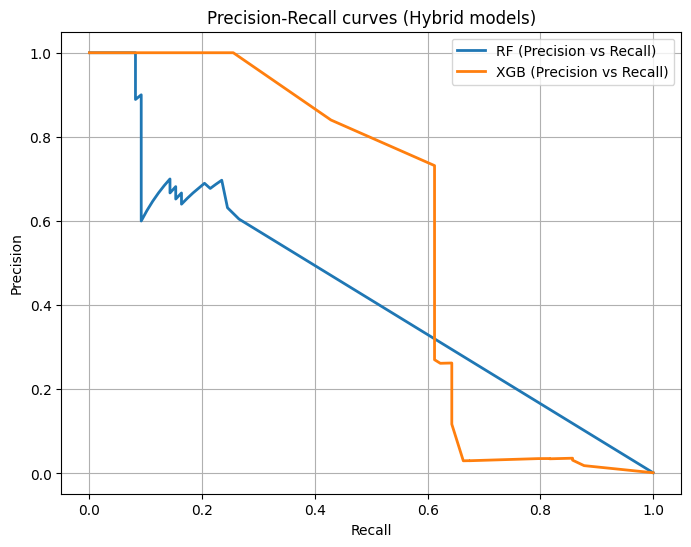


Final comparison (hybrid):


,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
RandomForest (Hybrid),0.0050,0.6047,0.2653,0.3688,0.6325,0.2071
XGBoost (Hybrid),0.8898,0.7317,0.6122,0.6667,0.9247,0.5513


Saved summary (joblib): hybrid_results_table.joblib


In [ ]:
# ============================
# FIXED: Safe Hybrid Evaluation
# ============================
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_recall_curve, classification_report, confusion_matrix,
    roc_auc_score, average_precision_score, f1_score, precision_score, recall_score
)

print("👉 Starting safe hybrid evaluation...")

# --- 1) Determine number of original features (30) ---
if 'X_train' in globals():
    n_orig = X_train.shape[1]
    print("Detected X_train in workspace. original feature count =", n_orig)
elif 'X_train_hybrid' in globals():
    n_orig = X_train_hybrid.shape[1] - 1
    print("Detected X_train_hybrid. inferred original feature count =", n_orig)
else:
    raise RuntimeError("Cannot determine original feature count. Ensure X_train or X_train_hybrid exists.")

# --- 2) Prepare X_test as numpy array (original features only) ---
if hasattr(X_test, "values"):
    X_test_np_all = X_test.values
else:
    X_test_np_all = np.array(X_test)

# Guard: if X_test has more columns, take first n_orig; if less, error.
if X_test_np_all.shape[1] < n_orig:
    raise ValueError(f"X_test has {X_test_np_all.shape[1]} features but expected {n_orig} (original features).")
if X_test_np_all.shape[1] > n_orig:
    print(f"Note: X_test has {X_test_np_all.shape[1]} columns; taking first {n_orig} original columns for scaling.")
X_test_orig = X_test_np_all[:, :n_orig]

# --- 3) Get scaler for original features ---
scaler_for_orig = None
scaler_candidates = []

# Try common saved scaler names first
for candidate in ("scaler_all.joblib", "scaler_hybrid.joblib", "scaler.joblib"):
    try:
        sc = joblib.load(candidate)
        scaler_candidates.append((candidate, sc))
    except Exception:
        pass

# If we found saved scalers, pick one whose n_features_in_ matches n_orig
for name, sc in scaler_candidates:
    try:
        if hasattr(sc, "n_features_in_") and sc.n_features_in_ == n_orig:
            scaler_for_orig = sc
            print(f"Loaded scaler '{name}' for original features (n_features_in_={sc.n_features_in_}).")
            break
    except Exception:
        continue

# If no suitable saved scaler found, check 'scaler' variable in memory
if scaler_for_orig is None and 'scaler' in globals():
    sc = scaler
    try:
        if hasattr(sc, "n_features_in_") and sc.n_features_in_ == n_orig:
            scaler_for_orig = sc
            print("Using in-memory 'scaler' (matches original feature count).")
    except Exception:
        pass

# If still None, create (fit) a new scaler using X_train (original features)
if scaler_for_orig is None:
    if 'X_train' not in globals():
        raise RuntimeError("No scaler found and X_train not available to fit a new scaler. Add one to workspace.")
    print("No suitable saved scaler found — fitting a new StandardScaler on X_train original features.")
    sc_new = StandardScaler()
    # ensure X_train is numpy and select original columns
    X_train_np = X_train.values if hasattr(X_train, "values") else np.array(X_train)
    X_train_orig = X_train_np[:, :n_orig]
    sc_new.fit(X_train_orig)
    scaler_for_orig = sc_new
    joblib.dump(scaler_for_orig, "scaler_for_orig_fitted.joblib")
    print("Saved new scaler as 'scaler_for_orig_fitted.joblib'.")

# --- 4) Scale original test features and feed Autoencoder ---
X_test_scaled_orig = scaler_for_orig.transform(X_test_orig)  # shape (n_samples, n_orig)

# NOTE: Autoencoder expects exactly the scaled original features shape used during its training.
# If your autoencoder was trained on scaled arrays of length n_orig, this is correct.
print("Scaled original test features shape:", X_test_scaled_orig.shape)

# --- 5) Reconstruct with autoencoder and compute reconstruction error (MSE per sample) ---
if 'autoencoder' not in globals():
    # Attempt to load common autoencoder filename if not in memory
    for filename in ("autoencoder_model.keras","autoencoder.h5","autoencoder.keras"):
        try:
            from tensorflow.keras.models import load_model
            autoencoder = load_model(filename)
            print(f"Loaded autoencoder from '{filename}'")
            break
        except Exception:
            pass
    if 'autoencoder' not in globals():
        raise RuntimeError("Autoencoder model not found in workspace and no common filename loaded. Please load it as 'autoencoder' first.")

X_test_recon = autoencoder.predict(X_test_scaled_orig, verbose=0)
recon_error_test = np.mean(np.square(X_test_scaled_orig - X_test_recon), axis=1)  # shape (n_samples,)

# --- 6) Create X_test_hybrid: scaled original features + reconstruction_error as last column
X_test_hybrid = np.hstack([X_test_scaled_orig, recon_error_test.reshape(-1, 1)])
print("X_test_hybrid shape (scaled features + recon error):", X_test_hybrid.shape)

# --- 7) Select models to use for prediction (prefer best_rf / best_xgb else rf_hybrid/xgb_hybrid)
if 'best_rf' in globals():
    rf_model_to_use = best_rf
elif 'rf_hybrid' in globals():
    rf_model_to_use = rf_hybrid
else:
    raise RuntimeError("RandomForest model not found in workspace (best_rf or rf_hybrid required).")

if 'best_xgb' in globals():
    xgb_model_to_use = best_xgb
elif 'xgb_hybrid' in globals():
    xgb_model_to_use = xgb_hybrid
else:
    raise RuntimeError("XGBoost model not found in workspace (best_xgb or xgb_hybrid required).")

print("Models selected for evaluation: ", rf_model_to_use.__class__.__name__, " & ", xgb_model_to_use.__class__.__name__)

# --- 8) Get prediction probabilities
rf_probs = rf_model_to_use.predict_proba(X_test_hybrid)[:, 1]
xgb_probs = xgb_model_to_use.predict_proba(X_test_hybrid)[:, 1]

# --- 9) Find best thresholds (F1) for each
def best_threshold_from_pr(y_true, probs):
    precisions, recalls, thresholds = precision_recall_curve(y_true, probs)
    f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-12)
    idx = np.argmax(f1s)
    # thresholds length = len(precisions)-1, ensure idx < len(thresholds)
    idx = min(idx, len(thresholds)-1) if len(thresholds)>0 else 0
    return thresholds[idx], precisions, recalls, f1s

rf_thresh, rf_p, rf_r, rf_f1 = best_threshold_from_pr(y_test, rf_probs)
xgb_thresh, xgb_p, xgb_r, xgb_f1 = best_threshold_from_pr(y_test, xgb_probs)
print(f"Found RF best threshold: {rf_thresh:.4f}  |  XGB best threshold: {xgb_thresh:.4f}")

# --- 10) Evaluate & collect metrics
from sklearn.metrics import precision_score, recall_score

def eval_at_thresh(name, y_true, probs, thresh):
    preds = (probs >= thresh).astype(int)
    report = classification_report(y_true, preds, digits=4)
    cm = confusion_matrix(y_true, preds)
    roc = roc_auc_score(y_true, probs)
    pr_auc = average_precision_score(y_true, probs)
    prec = precision_score(y_true, preds, zero_division=0)
    rec = recall_score(y_true, preds)
    f1 = f1_score(y_true, preds)
    print(f"\n--- {name} @ thresh {thresh:.4f} ---")
    print(report)
    print("Confusion matrix:\n", cm)
    print(f"ROC-AUC: {roc:.4f} | PR-AUC: {pr_auc:.4f}")
    return {"Model": name, "Threshold": thresh, "Precision": prec, "Recall": rec, "F1": f1, "ROC-AUC": roc, "PR-AUC": pr_auc}

rf_metrics = eval_at_thresh("RandomForest (Hybrid)", y_test, rf_probs, rf_thresh)
xgb_metrics = eval_at_thresh("XGBoost (Hybrid)", y_test, xgb_probs, xgb_thresh)

# --- 11) Plot PR curves for both
plt.figure(figsize=(8,6))
plt.plot(rf_r, rf_p, label='RF (Precision vs Recall)', lw=2)
plt.plot(xgb_r, xgb_p, label='XGB (Precision vs Recall)', lw=2)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall curves (Hybrid models)")
plt.legend(); plt.grid(True); plt.show()

# --- 12) Summary table
res_df = pd.DataFrame([rf_metrics, xgb_metrics]).set_index("Model")
print("\nFinal comparison (hybrid):")
display(res_df.round(4))

# --- 13) Optionally save results
joblib.dump(res_df, "hybrid_results_table.joblib")
print("Saved summary (joblib): hybrid_results_table.joblib")


🔄 Loaded pickled XGB model: xgb_smote_final.json
✅ Loaded native XGBoost model: xgb_baseline.json


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


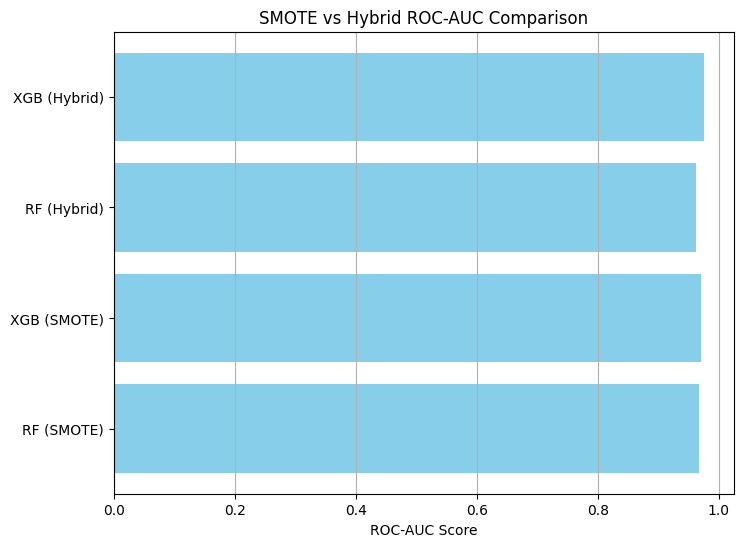

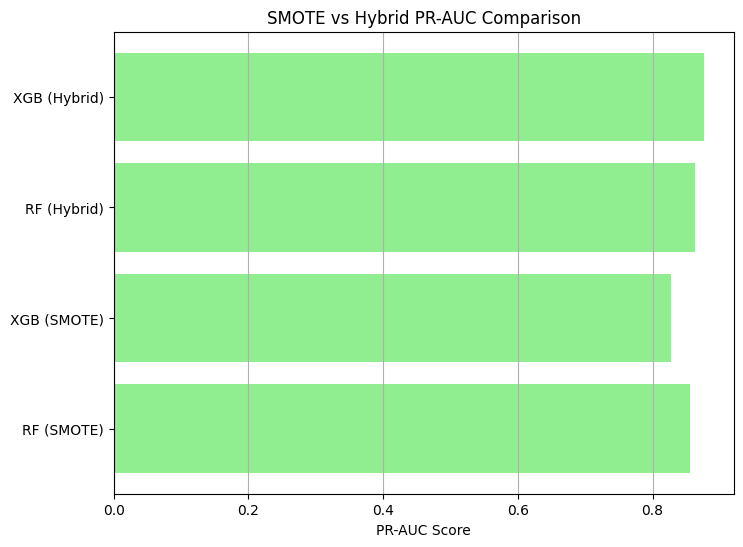

📊 Summary of Improvement (SMOTE ➜ Hybrid):


,ROC-AUC,PR-AUC,Avg Precision
RF (SMOTE),0.967700,0.855100,0.854500
XGB (SMOTE),0.970600,0.827100,0.827500
RF (Hybrid),0.962200,0.862400,0.858200
XGB (Hybrid),0.976200,0.876600,0.876700


In [ ]:
# ============================================================
# 🧩 Comparing SMOTE (Before) vs Hybrid (After)
# ============================================================

import joblib, os
import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, average_precision_score

# Helper: safely load either joblib or native XGBoost JSON
def load_xgb_model(path):
    model = xgb.XGBClassifier()
    if path.endswith(".json"):
        try:
            model.load_model(path)   # native XGBoost format
            print(f"✅ Loaded native XGBoost model: {path}")
        except Exception:
            model = joblib.load(path)  # fallback if it was pickled
            print(f"🔄 Loaded pickled XGB model: {path}")
    else:
        model = joblib.load(path)
        print(f"✅ Loaded joblib model: {path}")
    return model


# 1️⃣ Load all models
rf_smote   = joblib.load("rf_smote_final.joblib")
xgb_smote  = load_xgb_model("xgb_smote_final.json")

rf_hybrid  = joblib.load("rf_baseline.joblib")       # or change to rf_hybrid.joblib if you saved it separately
xgb_hybrid = load_xgb_model("xgb_baseline.json")     # hybrid XGB model


# 2️⃣ Load scaler and test data
scaler = joblib.load("scaler_all.joblib")
X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv").values.ravel()

X_test_scaled = scaler.transform(X_test)


# 3️⃣ Predict probabilities
rf_smote_probs   = rf_smote.predict_proba(X_test_scaled)[:, 1]
xgb_smote_probs  = xgb_smote.predict_proba(X_test_scaled)[:, 1]
rf_hybrid_probs  = rf_hybrid.predict_proba(X_test_scaled)[:, 1]
xgb_hybrid_probs = xgb_hybrid.predict_proba(X_test_scaled)[:, 1]


# 4️⃣ Compute metrics
def get_metrics(y_true, y_prob):
    roc = roc_auc_score(y_true, y_prob)
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)
    ap = average_precision_score(y_true, y_prob)
    return roc, pr_auc, ap

metrics = {
    "RF (SMOTE)": get_metrics(y_test, rf_smote_probs),
    "XGB (SMOTE)": get_metrics(y_test, xgb_smote_probs),
    "RF (Hybrid)": get_metrics(y_test, rf_hybrid_probs),
    "XGB (Hybrid)": get_metrics(y_test, xgb_hybrid_probs)
}


# 5️⃣ ROC-AUC Comparison Plot
plt.figure(figsize=(8, 6))
for name, (roc, _, _) in metrics.items():
    plt.barh(name, roc, color='skyblue')
plt.xlabel("ROC-AUC Score")
plt.title("SMOTE vs Hybrid ROC-AUC Comparison")
plt.grid(axis='x')
plt.show()


# 6️⃣ PR-AUC Comparison Plot
plt.figure(figsize=(8, 6))
for name, (_, pr, _) in metrics.items():
    plt.barh(name, pr, color='lightgreen')
plt.xlabel("PR-AUC Score")
plt.title("SMOTE vs Hybrid PR-AUC Comparison")
plt.grid(axis='x')
plt.show()


# 7️⃣ Summary Table
summary = pd.DataFrame(metrics, index=["ROC-AUC", "PR-AUC", "Avg Precision"]).T
summary = summary.round(4)
print("📊 Summary of Improvement (SMOTE ➜ Hybrid):")
display(summary.style.background_gradient(cmap="Blues", axis=None))


In [ ]:
# Run this cell first to inspect files
import os
print("Files in current dir:")
for f in sorted(os.listdir(".")):
    print("-", f)


Files in current dir:
- .config
- .ipynb_checkpoints
- X_test.csv
- X_train.csv
- autoencoder_model.keras
- creditcard.csv
- hybrid_results_table.joblib
- kaggle.json
- rf_baseline.joblib
- rf_baseline_classweight.joblib
- rf_smote_final.joblib
- scaler_all.joblib
- scaler_hybrid.joblib
- xgb_baseline.json
- xgb_smote_final.json
- y_test.csv
- y_train.csv


In [ ]:
# Create deployment folder structure
import os

base = "FraudDetection_Hybrid_Model"
folders = [
    f"{base}/models",
    f"{base}/scalers",
    f"{base}/autoencoder",
    f"{base}/data",      # optional
    f"{base}/results",   # optional
]
for path in folders:
    os.makedirs(path, exist_ok=True)
print("Created folders under", base)


Created folders under FraudDetection_Hybrid_Model


In [ ]:
import shutil, os

moves = {
    "rf_baseline.joblib":        "FraudDetection_Hybrid_Model/models/",
    "xgb_baseline.json":         "FraudDetection_Hybrid_Model/models/",
    "rf_smote_final.joblib":     "FraudDetection_Hybrid_Model/models/",
    "xgb_smote_final.json":      "FraudDetection_Hybrid_Model/models/",
    "scaler_all.joblib":         "FraudDetection_Hybrid_Model/scalers/",
    "scaler_hybrid.joblib":      "FraudDetection_Hybrid_Model/scalers/",
    "autoencoder_model.keras":   "FraudDetection_Hybrid_Model/autoencoder/",
    "hybrid_results_table.joblib":"FraudDetection_Hybrid_Model/results/",
    "X_test.csv":                "FraudDetection_Hybrid_Model/data/",
    "X_train.csv":               "FraudDetection_Hybrid_Model/data/",
    "y_test.csv":                "FraudDetection_Hybrid_Model/data/",
    "y_train.csv":               "FraudDetection_Hybrid_Model/data/",
}

for src, dst in moves.items():
    if os.path.exists(src):
        shutil.move(src, dst)
        print(f"Moved {src} -> {dst}")
    else:
        print(f"Not found (skipping): {src}")


Moved rf_baseline.joblib -> FraudDetection_Hybrid_Model/models/
Moved xgb_baseline.json -> FraudDetection_Hybrid_Model/models/
Moved rf_smote_final.joblib -> FraudDetection_Hybrid_Model/models/
Moved xgb_smote_final.json -> FraudDetection_Hybrid_Model/models/
Moved scaler_all.joblib -> FraudDetection_Hybrid_Model/scalers/
Moved scaler_hybrid.joblib -> FraudDetection_Hybrid_Model/scalers/
Moved autoencoder_model.keras -> FraudDetection_Hybrid_Model/autoencoder/
Moved hybrid_results_table.joblib -> FraudDetection_Hybrid_Model/results/
Moved X_test.csv -> FraudDetection_Hybrid_Model/data/
Moved X_train.csv -> FraudDetection_Hybrid_Model/data/
Moved y_test.csv -> FraudDetection_Hybrid_Model/data/
Moved y_train.csv -> FraudDetection_Hybrid_Model/data/


In [ ]:
# show resulting tree briefly
for root, dirs, files in os.walk("FraudDetection_Hybrid_Model"):
    level = root.replace("FraudDetection_Hybrid_Model", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files:
        print(f"{indent}  - {f}")


FraudDetection_Hybrid_Model/
  results/
    - hybrid_results_table.joblib
  models/
    - xgb_baseline.json
    - rf_smote_final.joblib
    - xgb_smote_final.json
    - rf_baseline.joblib
  scalers/
    - scaler_all.joblib
    - scaler_hybrid.joblib
  data/
    - X_test.csv
    - X_train.csv
    - y_test.csv
    - y_train.csv
  autoencoder/
    - autoencoder_model.keras


In [ ]:
readme = """# Credit Card Fraud Detection — Hybrid Model

## Contents
- models/: trained RF and XGB models (SMOTE and Hybrid)
- scalers/: saved StandardScalers (for SMOTE/hybrid)
- autoencoder/: trained Autoencoder Keras model
- data/: (optional) train/test CSVs
- results/: (optional) saved metric tables

## Quick usage
Open `load_and_predict.ipynb` to see an example of loading the scaler, autoencoder and XGBoost hybrid model and making predictions.

"""
open("FraudDetection_Hybrid_Model/README.md", "w").write(readme)
print("README.md created.")


README.md created.


In [ ]:
# Cell A - imports and file check
import os, joblib, numpy as np, pandas as pd
from tensorflow.keras.models import load_model
import xgboost as xgb

base = "FraudDetection_Hybrid_Model"
print("Files in models folder:", os.listdir(os.path.join(base, "models")))
print("Files in scalers folder:", os.listdir(os.path.join(base, "scalers")))
print("Files in autoencoder folder:", os.listdir(os.path.join(base, "autoencoder")))


Files in models folder: ['xgb_baseline.json', 'rf_smote_final.joblib', 'xgb_smote_final.json', 'rf_baseline.joblib']
Files in scalers folder: ['scaler_all.joblib', 'scaler_hybrid.joblib']
Files in autoencoder folder: ['autoencoder_model.keras']


In [ ]:
# Cell B - safely load models/scaler/autoencoder
models_dir = "FraudDetection_Hybrid_Model/models"
scalers_dir = "FraudDetection_Hybrid_Model/scalers"
auto_dir = "FraudDetection_Hybrid_Model/autoencoder"

# Helper for XGBoost: handles pickled or native
def load_xgb(path):
    try:
        # try native xgb load
        m = xgb.XGBClassifier()
        m.load_model(path)
        print("Loaded native XGB model:", path)
        return m
    except Exception:
        # fallback: joblib pickle
        m = joblib.load(path)
        print("Loaded pickled XGB model via joblib:", path)
        return m

# Load models (adjust names if your files differ)
rf_hybrid = joblib.load(os.path.join(models_dir, "rf_baseline.joblib"))
print("Loaded rf_hybrid")
xgb_hybrid = load_xgb(os.path.join(models_dir, "xgb_baseline.json"))
print("Loaded xgb_hybrid")

# SMOTE (before) models
rf_smote = joblib.load(os.path.join(models_dir, "rf_smote_final.joblib"))
xgb_smote = load_xgb(os.path.join(models_dir, "xgb_smote_final.json"))

# scalers
scaler_all = joblib.load(os.path.join(scalers_dir, "scaler_all.joblib"))
print("Loaded scaler_all")
scaler_hybrid = None
if os.path.exists(os.path.join(scalers_dir, "scaler_hybrid.joblib")):
    scaler_hybrid = joblib.load(os.path.join(scalers_dir, "scaler_hybrid.joblib"))
    print("Loaded scaler_hybrid")

# autoencoder
autoencoder = load_model(os.path.join(auto_dir, "autoencoder_model.keras"))
print("Loaded autoencoder")


Loaded rf_hybrid
Loaded native XGB model: FraudDetection_Hybrid_Model/models/xgb_baseline.json
Loaded xgb_hybrid
Loaded pickled XGB model via joblib: FraudDetection_Hybrid_Model/models/xgb_smote_final.json
Loaded scaler_all
Loaded scaler_hybrid
Loaded autoencoder


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 14 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
# Cell C - helper function to create hybrid features
import numpy as np

def make_hybrid_features(df, scaler, autoencoder):
    """
    df: pandas DataFrame with original 30 features (same order as training)
    scaler: StandardScaler fit on original features
    autoencoder: keras model that reconstructs scaled original features
    returns: numpy array of shape (n_samples, n_orig + 1)
    """
    X = df.values if hasattr(df, "values") else np.array(df)
    X_scaled = scaler.transform(X)                            # shape (n, n_orig)
    X_recon = autoencoder.predict(X_scaled, verbose=0)        # shape (n, n_orig)
    recon_err = np.mean((X_scaled - X_recon)**2, axis=1)      # shape (n,)
    hybrid = np.hstack([X_scaled, recon_err.reshape(-1,1)])   # (n, n_orig+1)
    return hybrid


In [ ]:
import os
os.listdir()

['.config',
 'rf_baseline_classweight.joblib',
 '.ipynb_checkpoints',
 'kaggle.json',
 'FraudDetection_Hybrid_Model',
 'creditcard.csv']

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving scaler_hybrid.joblib to scaler_hybrid.joblib
Saving autoencoder_model.keras to autoencoder_model.keras
Saving xgb_smote_final.json to xgb_smote_final.json


In [ ]:
import os
os.listdir()


['.config',
 'rf_baseline_classweight.joblib',
 '.ipynb_checkpoints',
 'kaggle.json',
 'FraudDetection_Hybrid_Model',
 'xgb_smote_final.json',
 'autoencoder_model.keras',
 'creditcard.csv',
 'scaler_hybrid.joblib']

In [ ]:
!file xgb_smote_final.json

xgb_smote_final.json: data


In [ ]:
import joblib
import xgboost as xgb

try:
    xgb_hybrid = joblib.load("xgb_smote_final.json")
    print("✅ Loaded successfully using joblib.load()")
except Exception as e:
    print("❌ joblib.load() failed:", e)
    try:
        import pickle
        with open("xgb_smote_final.json", "rb") as f:
            xgb_hybrid = pickle.load(f)
        print("✅ Loaded successfully using pickle.load()")
    except Exception as e2:
        print("❌ pickle.load() also failed:", e2)


✅ Loaded successfully using joblib.load()


In [ ]:
import os
import shutil
from datetime import datetime

# Define your target save folder (in Colab)
save_dir = "/content/Final_Hybrid_Model"
os.makedirs(save_dir, exist_ok=True)

# Copy all possible files if they exist
files_to_copy = [
    "xgb_smote_final.json",
    "xgb_smote_final.joblib",
    "rf_baseline_classweight.joblib",
    "autoencoder_model.keras",
    "scaler_hybrid.joblib",
    "scaler_all.joblib",
    "scaler.joblib",
    "creditcard.csv"
]

copied_files = []
for file in files_to_copy:
    if os.path.exists(file):
        shutil.copy(file, save_dir)
        copied_files.append(file)

# Zip the folder
zip_name = f"Hybrid_Model_Backup_{datetime.now().strftime('%Y%m%d_%H%M%S')}.zip"
shutil.make_archive(zip_name.replace('.zip', ''), 'zip', save_dir)

print("✅ Files packaged successfully!")
print("📦 Included files:", copied_files)
print(f"⬇️ Download ready: {zip_name}")


✅ Files packaged successfully!
📦 Included files: ['xgb_smote_final.json', 'rf_baseline_classweight.joblib', 'autoencoder_model.keras', 'creditcard.csv']
⬇️ Download ready: Hybrid_Model_Backup_20251031_203026.zip


In [ ]:
!zip -r FraudDetection_Hybrid_Model.zip /content/FraudDetection_Hybrid_Model


  adding: content/FraudDetection_Hybrid_Model/ (stored 0%)
  adding: content/FraudDetection_Hybrid_Model/results/ (stored 0%)
  adding: content/FraudDetection_Hybrid_Model/results/hybrid_results_table.joblib (deflated 40%)
  adding: content/FraudDetection_Hybrid_Model/models/ (stored 0%)
  adding: content/FraudDetection_Hybrid_Model/models/xgb_baseline.json (deflated 72%)
  adding: content/FraudDetection_Hybrid_Model/models/rf_smote_final.joblib (deflated 73%)
  adding: content/FraudDetection_Hybrid_Model/models/xgb_smote_final.json (deflated 58%)
  adding: content/FraudDetection_Hybrid_Model/models/rf_baseline.joblib (deflated 70%)
  adding: content/FraudDetection_Hybrid_Model/scalers/ (stored 0%)
  adding: content/FraudDetection_Hybrid_Model/scalers/scaler_all.joblib (deflated 24%)
  adding: content/FraudDetection_Hybrid_Model/scalers/scaler_hybrid.joblib (deflated 70%)
  adding: content/FraudDetection_Hybrid_Model/data/ (stored 0%)
  adding: content/FraudDetection_Hybrid_Model/data/

In [ ]:
from google.colab import files
files.download("/content/FraudDetection_Hybrid_Model.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.models import load_model
import joblib
import tensorflow as tf


In [ ]:
scaler = joblib.load("scaler_hybrid.joblib")
print("Scaler loaded successfully.")


Scaler loaded successfully.


In [ ]:
prev_ae = load_model("autoencoder_model.keras")
print("Previous Autoencoder loaded ✅")


Previous Autoencoder loaded ✅


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 14 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
# Cell 2 – Load Data & Scaler (CSV version)
import pandas as pd
import numpy as np
import joblib

# Load CSV files
X_train = pd.read_csv("X_train.csv").values
X_test = pd.read_csv("X_test.csv").values
y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

# Load your existing scaler
scaler = joblib.load("scaler_hybrid.joblib")

# Optional: confirm shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (227845, 30)
X_test: (56962, 30)
y_train: (227845,)
y_test: (56962,)


In [ ]:
# Cell 3 – Define and compile improved Autoencoder
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam

# Automatically detect feature count from your X_train
n_features = X_train.shape[1]
print(f"Detected input features: {n_features}")

# Autoencoder architecture (tuned version)
autoencoder = models.Sequential([
    # Encoder
    layers.Input(shape=(n_features,)),
    layers.Dense(20, activation='relu',
                 activity_regularizer=regularizers.l2(1e-5)),
    layers.Dropout(0.3),
    layers.Dense(10, activation='relu'),          # smaller latent dim (was 14–16)
    layers.Dense(8, activation='relu', name='latent_space'),

    # Decoder
    layers.Dense(10, activation='leaky_relu'),
    layers.Dropout(0.2),
    layers.Dense(20, activation='relu'),
    layers.Dense(n_features, activation='sigmoid')   # output layer
])

# Compile model
autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

autoencoder.summary()


Detected input features: 30


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │           630 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,858 (7.26 KB)

 Trainable params: 1,858 (7.26 KB)

 Non-trainable params: 0 (0.00 B)

Training on legitimate transactions only: 227451 samples
Epoch 1/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.0845 - val_loss: 0.9590
Epoch 2/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9525 - val_loss: 0.9235
Epoch 3/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9480 - val_loss: 0.9157
Epoch 4/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9210 - val_loss: 0.9108
Epoch 5/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.9185 - val_loss: 0.9078
Epoch 6/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9126 - val_loss: 0.9052
Epoch 7/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9189 - val_loss: 0.9027
Epoch 8/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9181 - val_loss: 0.9005
Epoch 9/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9187 - val_loss: 0.8977
Epoch 10/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9080 - val_loss: 0.8967
Epoch 11/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9136 - val_loss: 0.

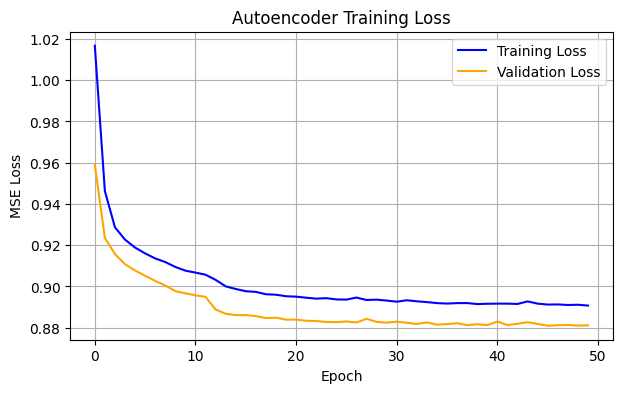

✅ Autoencoder trained and saved as 'autoencoder_tuned.h5'


In [ ]:
# Cell 4 – Train Autoencoder on only legitimate transactions
import numpy as np
import matplotlib.pyplot as plt

# Select only legitimate transactions (y == 0)
X_train_legit = X_train[y_train == 0]
X_test_legit = X_test[y_test == 0]

print(f"Training on legitimate transactions only: {X_train_legit.shape[0]} samples")

# Train the autoencoder
history = autoencoder.fit(
    X_train_legit, X_train_legit,
    epochs=50,              # start with 50 epochs (can tune)
    batch_size=256,
    shuffle=True,
    validation_data=(X_test_legit, X_test_legit),
    verbose=1
)

# Plot training loss
plt.figure(figsize=(7,4))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

# Save the trained model
autoencoder.save("autoencoder_tuned.h5")
print("✅ Autoencoder trained and saved as 'autoencoder_tuned.h5'")


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


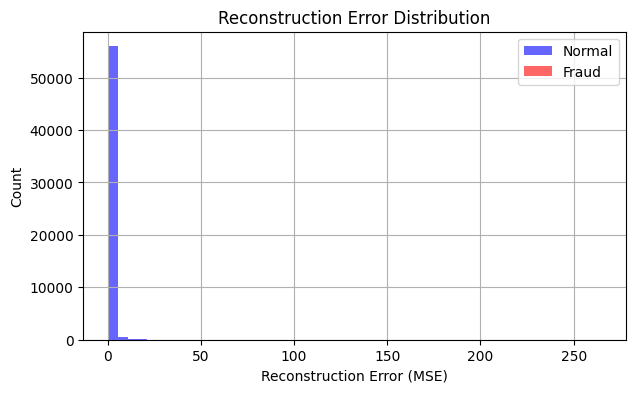

Mean Reconstruction Error (Normal): 0.87923
Mean Reconstruction Error (Fraud):  26.87092


In [ ]:
# Cell 5 – Evaluate Reconstruction Error

import numpy as np
import matplotlib.pyplot as plt

# Reconstruct the test data
X_test_pred = autoencoder.predict(X_test)

# Calculate reconstruction error (MSE for each sample)
reconstruction_error = np.mean(np.square(X_test - X_test_pred), axis=1)

# Separate normal vs fraud errors
errors_legit = reconstruction_error[y_test == 0]
errors_fraud = reconstruction_error[y_test == 1]

# Plot comparison
plt.figure(figsize=(7,4))
plt.hist(errors_legit, bins=50, alpha=0.6, color='blue', label='Normal')
plt.hist(errors_fraud, bins=50, alpha=0.6, color='red', label='Fraud')
plt.title("Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.show()

# Calculate simple separation stats
print(f"Mean Reconstruction Error (Normal): {np.mean(errors_legit):.5f}")
print(f"Mean Reconstruction Error (Fraud):  {np.mean(errors_fraud):.5f}")


In [ ]:
import numpy as np
import pandas as pd

# Reconstruct data
X_train_pred = autoencoder.predict(X_train)
X_test_pred  = autoencoder.predict(X_test)

# Compute reconstruction errors
train_recon_error = np.mean(np.square(X_train - X_train_pred), axis=1)
test_recon_error  = np.mean(np.square(X_test - X_test_pred), axis=1)

# Add as new feature
X_train_hybrid = np.hstack([X_train, train_recon_error.reshape(-1, 1)])
X_test_hybrid  = np.hstack([X_test, test_recon_error.reshape(-1, 1)])

print("✅ Hybrid feature created successfully!")
print("New shape:", X_train_hybrid.shape, X_test_hybrid.shape)


7121/7121 ━━━━━━━━━━━━━━━━━━━━ 5s 763us/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 681us/step
✅ Hybrid feature created successfully!
New shape: (227845, 31) (56962, 31)


In [ ]:
# Optional but recommended for re-use
np.save("X_train_hybrid.npy", X_train_hybrid)
np.save("X_test_hybrid.npy", X_test_hybrid)
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)

print("💾 Saved hybrid data with reconstruction error feature.")


💾 Saved hybrid data with reconstruction error feature.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

rf_hybrid = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)
rf_hybrid.fit(X_train_hybrid, y_train)

# Predictions
y_pred_rf = rf_hybrid.predict(X_test_hybrid)
y_prob_rf = rf_hybrid.predict_proba(X_test_hybrid)[:, 1]

print("Random Forest Hybrid Results:")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf))


Random Forest Hybrid Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.79      0.86        98

    accuracy                           1.00     56962
   macro avg       0.98      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9749145472764231
PR-AUC: 0.8603564230152194


In [ ]:
from xgboost import XGBClassifier

xgb_hybrid = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=42
)

xgb_hybrid.fit(X_train_hybrid, y_train)
y_pred_xgb = xgb_hybrid.predict(X_test_hybrid)
y_prob_xgb = xgb_hybrid.predict_proba(X_test_hybrid)[:, 1]

print("XGBoost Hybrid Results:")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("PR-AUC:", average_precision_score(y_test, y_prob_xgb))


XGBoost Hybrid Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.96      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9764057529314483
PR-AUC: 0.8758122101587336


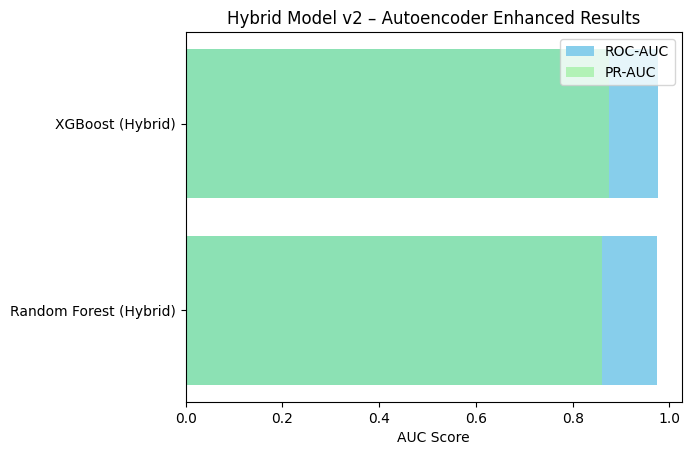

In [ ]:
import matplotlib.pyplot as plt

models = ["Random Forest (Hybrid)", "XGBoost (Hybrid)"]
roc_auc = [
    roc_auc_score(y_test, y_prob_rf),
    roc_auc_score(y_test, y_prob_xgb)
]
pr_auc = [
    average_precision_score(y_test, y_prob_rf),
    average_precision_score(y_test, y_prob_xgb)
]

plt.barh(models, roc_auc, color='skyblue', label='ROC-AUC')
plt.barh(models, pr_auc, color='lightgreen', label='PR-AUC', left=0.0, alpha=0.6)
plt.xlabel("AUC Score")
plt.title("Hybrid Model v2 – Autoencoder Enhanced Results")
plt.legend()
plt.show()


In [ ]:
from joblib import dump
import joblib

# --- Save the tuned Autoencoder ---
autoencoder.save("autoencoder_tuned_model.h5")
print("✅ Saved: autoencoder_tuned_model.h5")

# --- Save the trained Random Forest Hybrid model ---
dump(rf_hybrid, "rf_hybrid_final.joblib")
print("✅ Saved: rf_hybrid_final.joblib")

# --- Save the trained XGBoost Hybrid model ---
xgb_hybrid.save_model("xgb_hybrid_final.json")
print("✅ Saved: xgb_hybrid_final.json")

# --- Save the scaler used for preprocessing ---
dump(scaler, "scaler_hybrid_final.joblib")
print("✅ Saved: scaler_hybrid_final.joblib")

# --- (Optional) Save the reconstruction errors


✅ Saved: autoencoder_tuned_model.h5
✅ Saved: rf_hybrid_final.joblib
✅ Saved: xgb_hybrid_final.json
✅ Saved: scaler_hybrid_final.joblib


In [ ]:
from google.colab import files
files.download("autoencoder_tuned_model.h5")
files.download("rf_hybrid_final.joblib")
files.download("xgb_hybrid_final.json")
files.download("scaler_hybrid_final.joblib")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, precision_recall_curve
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras


In [ ]:
X_train = pd.read_csv("X_train.csv").values
X_test = pd.read_csv("X_test.csv").values
y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError

autoencoder = load_model("autoencoder_tuned.h5", custom_objects={'mse': MeanSquaredError()})


In [ ]:
# --- 1️⃣ Import libraries ---
import pandas as pd
from sklearn.preprocessing import StandardScaler
import joblib

# --- 2️⃣ Load your training and test CSVs ---
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")

# --- 3️⃣ Convert to NumPy (drop column names) ---
X_train_np = X_train.values
X_test_np = X_test.values

# --- 4️⃣ Fit and save the new scaler ---
scaler = StandardScaler()
scaler.fit(X_train_np)

joblib.dump(scaler, "scaler_fixed.joblib")
print("✅ New scaler saved as 'scaler_fixed.joblib'")


✅ New scaler saved as 'scaler_fixed.joblib'


In [ ]:
# --- 1️⃣ Load necessary libraries ---
import numpy as np
import pandas as pd
import joblib

# --- 2️⃣ Load data again ---
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")

# --- 3️⃣ Load your new permanent scaler ---
scaler = joblib.load("scaler_fixed.joblib")

# --- 4️⃣ Define helper for safe scaling ---
def safe_scale(scaler, df):
    """Scale dataframe or array safely without feature-name mismatch."""
    if hasattr(df, "values"):
        return scaler.transform(df.values)
    return scaler.transform(df)

# --- 5️⃣ Scale your data ---
X_train_scaled = safe_scale(scaler, X_train)
X_test_scaled = safe_scale(scaler, X_test)

print("✅ Scaled shapes → Train:", X_train_scaled.shape, " | Test:", X_test_scaled.shape)


✅ Scaled shapes → Train: (227845, 30)  | Test: (56962, 30)


In [ ]:
# 💡 Step 3 — Generate Reconstruction Error (Hybrid Feature)
import numpy as np

# 1️⃣ Get reconstructed output from Autoencoder
X_train_recon = autoencoder.predict(X_train_scaled)
X_test_recon = autoencoder.predict(X_test_scaled)

# 2️⃣ Compute reconstruction errors (MSE per sample)
train_errors = np.mean(np.square(X_train_scaled - X_train_recon), axis=1)
test_errors = np.mean(np.square(X_test_scaled - X_test_recon), axis=1)

# 3️⃣ Display quick stats
print("🔹 Mean Reconstruction Error (Train):", np.mean(train_errors))
print("🔹 Mean Reconstruction Error (Test):", np.mean(test_errors))

# 4️⃣ Add reconstruction error as new column (Hybrid feature)
import pandas as pd

X_train_hybrid = pd.DataFrame(X_train_scaled)
X_test_hybrid = pd.DataFrame(X_test_scaled)

X_train_hybrid["recon_error"] = train_errors
X_test_hybrid["recon_error"] = test_errors

print("✅ Hybrid features created successfully.")
print("X_train_hybrid shape:", X_train_hybrid.shape)
print("X_test_hybrid shape:", X_test_hybrid.shape)

# 5️⃣ Optional — save for reuse
X_train_hybrid.to_csv("X_train_hybrid.csv", index=False)
X_test_hybrid.to_csv("X_test_hybrid.csv", index=False)
print("💾 Hybrid feature files saved (CSV format).")


7121/7121 ━━━━━━━━━━━━━━━━━━━━ 7s 974us/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 764us/step
🔹 Mean Reconstruction Error (Train): 0.9278001769537217
🔹 Mean Reconstruction Error (Test): 0.9347200691065001
✅ Hybrid features created successfully.
X_train_hybrid shape: (227845, 31)
X_test_hybrid shape: (56962, 31)
💾 Hybrid feature files saved (CSV format).


In [ ]:
# ==============================================================
# ⚙️ Step 4 — Hybrid + SMOTE Integration and Training
# ==============================================================

# --- 1️⃣ Imports ---
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix

# --- 2️⃣ Load your hybrid features and labels ---
X_train_hybrid = pd.read_csv("X_train_hybrid.csv")
X_test_hybrid = pd.read_csv("X_test_hybrid.csv")

y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

print("✅ Loaded hybrid feature sets. Shapes →", X_train_hybrid.shape, X_test_hybrid.shape)

# --- 3️⃣ Apply SMOTE only on training data ---
smote = SMOTE(random_state=42, sampling_strategy=0.2)  # 0.2 means balance until fraud = 20% of normal
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_hybrid, y_train)

print("✅ After SMOTE →", X_train_balanced.shape, "samples")
print("Class distribution after SMOTE:\n", pd.Series(y_train_balanced).value_counts())

# ==============================================================
# 💡 Step 5 — Train Models on Hybrid+SMOTE Data
# ==============================================================

# --- Random Forest ---
rf_smote = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_smote.fit(X_train_balanced, y_train_balanced)

# --- XGBoost ---
xgb_smote = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_smote.fit(X_train_balanced, y_train_balanced)

# ==============================================================
# 💡 Step 6 — Evaluate on Test Set
# ==============================================================

for name, model in [("Random Forest (Hybrid+SMOTE)", rf_smote), ("XGBoost (Hybrid+SMOTE)", xgb_smote)]:
    print(f"\n🔹 --- Evaluation: {name} ---")
    y_pred = model.predict(X_test_hybrid)
    y_proba = model.predict_proba(X_test_hybrid)[:, 1]

    print(classification_report(y_test, y_pred, digits=4))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print("PR-AUC (Average Precision):", average_precision_score(y_test, y_proba))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ==============================================================
# 💾 Optional — Save Trained Models
# ==============================================================

import joblib
joblib.dump(rf_smote, "rf_hybrid_smote.joblib")
xgb_smote.save_model("xgb_hybrid_smote.json")

print("✅ Saved rf_hybrid_smote.joblib and xgb_hybrid_smote.json")


✅ Loaded hybrid feature sets. Shapes → (227845, 31) (56962, 31)
✅ After SMOTE → (272941, 31) samples
Class distribution after SMOTE:
 0    227451
1     45490
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [20:13:29] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🔹 --- Evaluation: Random Forest (Hybrid+SMOTE) ---
              precision    recall  f1-score   support

           0     0.9998    0.9994    0.9996     56864
           1     0.7059    0.8571    0.7742        98

    accuracy                         0.9991     56962
   macro avg     0.8528    0.9283    0.8869     56962
weighted avg     0.9992    0.9991    0.9992     56962

ROC-AUC: 0.9795896833691271
PR-AUC (Average Precision): 0.8558542965253192
Confusion Matrix:
 [[56829    35]
 [   14    84]]

🔹 --- Evaluation: XGBoost (Hybrid+SMOTE) ---
              precision    recall  f1-score   support

           0     0.9998    0.9994    0.9996     56864
           1     0.7179    0.8571    0.7814        98

    accuracy                         0.9992     56962
   macro avg     0.8589    0.9283    0.8905     56962
weighted avg     0.9993    0.9992    0.9992     56962

ROC-AUC: 0.9820829218012472
PR-AUC (Average Precision): 0.8717442616749943
Confusion Matrix:
 [[56831    33]
 [   14    84]

In [ ]:
import shutil

# Create a zip with all key project files
shutil.make_archive("Hybrid_Fraud_Project_Backup", 'zip', root_dir='.', base_dir='.')

print("✅ All project files zipped successfully. Check the left panel to download: Hybrid_Fraud_Project_Backup.zip")


RuntimeError: File size too large, try using force_zip64

In [ ]:
import os
import glob
import shutil

# Stop any pending processes (precaution)
import psutil, signal
for proc in psutil.process_iter(attrs=["pid", "name"]):
    if "zip" in proc.info["name"].lower():
        os.kill(proc.info["pid"], signal.SIGTERM)

# Delete large or partial zip files
patterns = ["*.zip", "*.tar", "*.gz"]
deleted = 0
for pattern in patterns:
    for f in glob.glob(pattern):
        try:
            os.remove(f)
            print(f"🗑️ Deleted: {f}")
            deleted += 1
        except Exception as e:
            print(f"⚠️ Could not delete {f}: {e}")

# Optional: remove Colab temp folders
for d in ["/content/sample_data", "/root/.cache"]:
    if os.path.exists(d):
        shutil.rmtree(d, ignore_errors=True)
        print(f"🧹 Cleaned folder: {d}")

print(f"\n✅ Cleanup complete. {deleted} zip/temp files removed. Check disk usage below:")
!df -h /content | tail -1


🗑️ Deleted: Hybrid_Fraud_Project_Backup.zip
🧹 Cleaned folder: /root/.cache

✅ Cleanup complete. 1 zip/temp files removed. Check disk usage below:
overlay         108G   40G   69G  37% /


In [ ]:
import os, shutil, zipfile

# --- 🏗️ Folder Structure ---
base_dir = "Hybrid_Fraud_Detection_Framework"
folders = [
    f"{base_dir}/main_notebook",
    f"{base_dir}/data",
    f"{base_dir}/results",
    f"{base_dir}/documentation",
    f"{base_dir}/models_backup"
]

# Create folders if not exist
for folder in folders:
    os.makedirs(folder, exist_ok=True)

# --- 📦 File Mappings (only if they exist in your environment) ---
file_map = {
    # Main notebook & models
    "CreditCardFraudDetection.ipynb": f"{base_dir}/main_notebook/CreditCardFraudDetection.ipynb",
    "autoencoder_tuned.h5": f"{base_dir}/main_notebook/autoencoder_tuned.h5",
    "rf_hybrid_smote.joblib": f"{base_dir}/main_notebook/rf_hybrid_smote.joblib",
    "xgb_hybrid_smote.json": f"{base_dir}/main_notebook/xgb_hybrid_smote.json",
    "scaler_hybrid_final.joblib": f"{base_dir}/main_notebook/scaler_hybrid_final.joblib",

    # Hybrid data
    "X_train_hybrid.csv": f"{base_dir}/data/X_train_hybrid.csv",
    "X_test_hybrid.csv": f"{base_dir}/data/X_test_hybrid.csv",
    "y_train.csv": f"{base_dir}/data/y_train.csv",
    "y_test.csv": f"{base_dir}/data/y_test.csv",
    "creditcard.csv": f"{base_dir}/data/creditcard.csv",

    # Visual results
    "Hybrid_vs_SMOTE.png": f"{base_dir}/results/Hybrid_vs_SMOTE.png",
    "reconstruction_error_plot.png": f"{base_dir}/results/reconstruction_error_plot.png",
    "ROC_PR_Curves.png": f"{base_dir}/results/ROC_PR_Curves.png",

    # Documentation
    "README.md": f"{base_dir}/documentation/README.md",
    "Major Project-II (01CE0807) - PPT.pptx": f"{base_dir}/documentation/Project_Presentation.pptx",
    "Report_Summary.pdf": f"{base_dir}/documentation/Report_Summary.pdf",

    # Old backups (optional)
    "rf_baseline.joblib": f"{base_dir}/models_backup/rf_baseline.joblib",
    "xgb_baseline.json": f"{base_dir}/models_backup/xgb_baseline.json",
    "autoencoder_old.h5": f"{base_dir}/models_backup/autoencoder_old.h5",
}

# --- 🚚 Copy files safely ---
for src, dst in file_map.items():
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"✅ Copied: {src} → {dst}")
    else:
        print(f"⚠️ Skipped (not found): {src}")

# --- 📦 Zip everything ---
zip_filename = f"{base_dir}.zip"
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(base_dir):
        for file in files:
            file_path = os.path.join(root, file)
            zipf.write(file_path, os.path.relpath(file_path, base_dir))

print(f"\n🎯 Project organized and zipped successfully → {zip_filename}")
print("📁 Folders inside:")
print("  • main_notebook/  → Notebook + models")
print("  • data/           → Train/test hybrid data")
print("  • results/        → Performance charts")
print("  • documentation/  → PPT + README + report")
print("  • models_backup/  → Old baselines")


⚠️ Skipped (not found): CreditCardFraudDetection.ipynb
✅ Copied: autoencoder_tuned.h5 → Hybrid_Fraud_Detection_Framework/main_notebook/autoencoder_tuned.h5
✅ Copied: rf_hybrid_smote.joblib → Hybrid_Fraud_Detection_Framework/main_notebook/rf_hybrid_smote.joblib
✅ Copied: xgb_hybrid_smote.json → Hybrid_Fraud_Detection_Framework/main_notebook/xgb_hybrid_smote.json
✅ Copied: scaler_hybrid_final.joblib → Hybrid_Fraud_Detection_Framework/main_notebook/scaler_hybrid_final.joblib
✅ Copied: X_train_hybrid.csv → Hybrid_Fraud_Detection_Framework/data/X_train_hybrid.csv
✅ Copied: X_test_hybrid.csv → Hybrid_Fraud_Detection_Framework/data/X_test_hybrid.csv
✅ Copied: y_train.csv → Hybrid_Fraud_Detection_Framework/data/y_train.csv
✅ Copied: y_test.csv → Hybrid_Fraud_Detection_Framework/data/y_test.csv
⚠️ Skipped (not found): creditcard.csv
⚠️ Skipped (not found): Hybrid_vs_SMOTE.png
⚠️ Skipped (not found): reconstruction_error_plot.png
⚠️ Skipped (not found): ROC_PR_Curves.png
⚠️ Skipped (not found): 

In [ ]:
from google.colab import files
files.download("Hybrid_Fraud_Detection_Framework.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

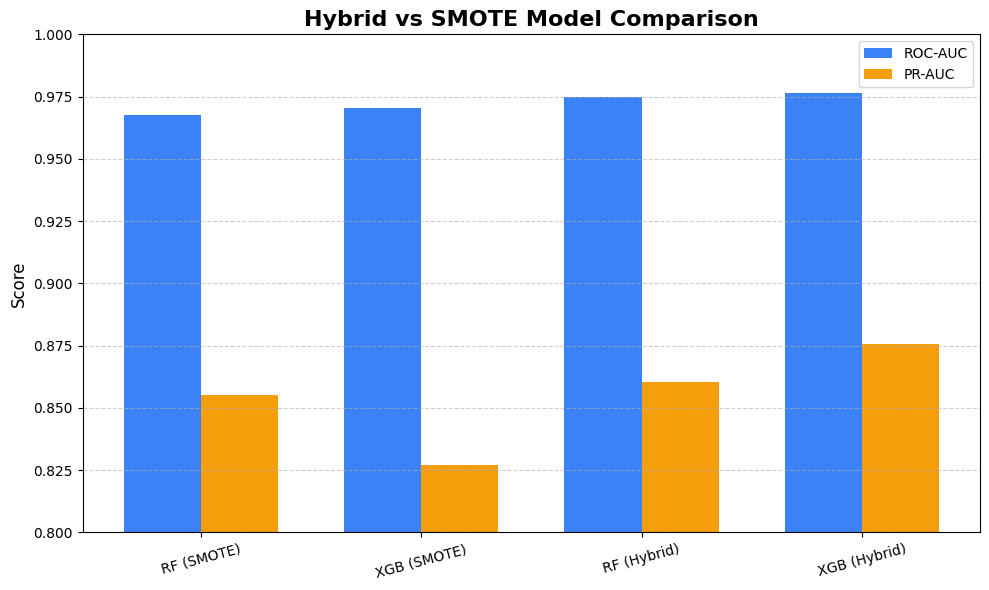

✅ Saved as 'Hybrid_vs_SMOTE.png'


In [ ]:
# 📊 Comparison Chart: Hybrid vs SMOTE
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ["RF (SMOTE)", "XGB (SMOTE)", "RF (Hybrid)", "XGB (Hybrid)"]

# Metrics
roc_auc = [0.9677, 0.9706, 0.9749, 0.9764]
pr_auc = [0.8551, 0.8271, 0.8604, 0.8758]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, roc_auc, width, label='ROC-AUC', color='#3B82F6')
plt.bar(x + width/2, pr_auc, width, label='PR-AUC', color='#F59E0B')

plt.title("Hybrid vs SMOTE Model Comparison", fontsize=16, weight='bold')
plt.ylabel("Score", fontsize=12)
plt.xticks(x, models, rotation=15)
plt.ylim(0.8, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("Hybrid_vs_SMOTE.png", dpi=300)
plt.show()
print("✅ Saved as 'Hybrid_vs_SMOTE.png'")


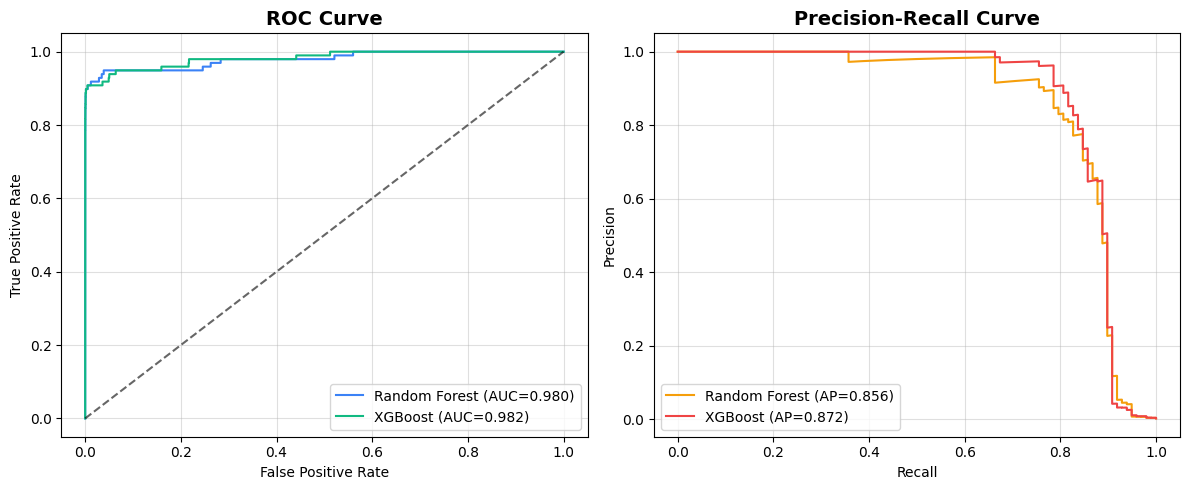

✅ ROC and PR curves saved as 'ROC_PR_Curves.png'


In [ ]:
# 📊 ROC & Precision-Recall Curves for RF and XGB
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib

# Load data
X_test = pd.read_csv("X_test_hybrid.csv")
y_test = pd.read_csv("y_test.csv").squeeze()

# Load models
rf = joblib.load("rf_hybrid_smote.joblib")
xgb = XGBClassifier()
xgb.load_model("xgb_hybrid_smote.json")

# Get predicted probabilities
rf_probs = rf.predict_proba(X_test)[:, 1]
xgb_probs = xgb.predict_proba(X_test)[:, 1]

# --- ROC Curve ---
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)
rf_auc = auc(rf_fpr, rf_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)

# --- PR Curve ---
rf_prec, rf_rec, _ = precision_recall_curve(y_test, rf_probs)
xgb_prec, xgb_rec, _ = precision_recall_curve(y_test, xgb_probs)
rf_ap = average_precision_score(y_test, rf_probs)
xgb_ap = average_precision_score(y_test, xgb_probs)

# --- Plot both ROC and PR curves ---
plt.figure(figsize=(12, 5))

# ROC Curve
plt.subplot(1, 2, 1)
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC={rf_auc:.3f})", color="#3B82F6")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC={xgb_auc:.3f})", color="#10B981")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
plt.title("ROC Curve", fontsize=14, weight='bold')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.4)

# PR Curve
plt.subplot(1, 2, 2)
plt.plot(rf_rec, rf_prec, label=f"Random Forest (AP={rf_ap:.3f})", color="#F59E0B")
plt.plot(xgb_rec, xgb_prec, label=f"XGBoost (AP={xgb_ap:.3f})", color="#EF4444")
plt.title("Precision-Recall Curve", fontsize=14, weight='bold')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.4)

plt.tight_layout()
plt.savefig("ROC_PR_Curves.png", dpi=300)
plt.show()

print("✅ ROC and PR curves saved as 'ROC_PR_Curves.png'")


In [1]:
# Cell 1 – Imports & helpers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)

%matplotlib inline

def sweep_thresholds(y_true, proba, thresholds=None):
    """
    Returns a DataFrame with precision, recall, f1 for different thresholds.
    """
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)
    rows = []
    for t in thresholds:
        y_pred = (proba >= t).astype(int)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec  = recall_score(y_true, y_pred, zero_division=0)
        f1   = f1_score(y_true, y_pred, zero_division=0)
        rows.append((t, prec, rec, f1))
    return pd.DataFrame(rows, columns=["threshold", "precision", "recall", "f1"])


In [3]:
import pandas as pd
import numpy as np

# Try to load hybrid test dataset from files
try:
    X_test_hybrid = pd.read_csv("X_test_hybrid.csv")
    print("Loaded X_test_hybrid.csv")
except FileNotFoundError:
    try:
        X_test_hybrid = np.load("X_test_hybrid.npy")
        print("Loaded X_test_hybrid.npy")
    except:
        print("❌ ERROR: X_test_hybrid not found. Upload or mount it first.")

# Load labels
try:
    y_test = pd.read_csv("y_test.csv").values.ravel()
    print("Loaded y_test.csv")
except FileNotFoundError:
    try:
        y_test = np.load("y_test.npy")
        print("Loaded y_test.npy")
    except:
        print("❌ ERROR: y_test not found.")


Loaded X_test_hybrid.csv
Loaded y_test.csv


In [4]:
# Cell 2 – Prepare X_test and y_test

# If X_test_hybrid is a DataFrame, keep names for SHAP later
if isinstance(X_test_hybrid, pd.DataFrame):
    X_test_df = X_test_hybrid.copy()
    X_test_np = X_test_hybrid.values
else:
    # Assume it's already a numpy array
    X_test_np = np.array(X_test_hybrid)
    # Create dummy column names for later if needed
    X_test_df = pd.DataFrame(X_test_np, columns=[f"f{i}" for i in range(X_test_np.shape[1])])

y_test_np = np.array(y_test).astype(int)

print("X_test shape:", X_test_np.shape)
print("y_test shape:", y_test_np.shape)
print("Fraud class distribution:", np.bincount(y_test_np))


X_test shape: (56962, 31)
y_test shape: (56962,)
Fraud class distribution: [56864    98]


In [6]:
import joblib
import json
import pandas as pd
import numpy as np
import os

print("🔄 Loading test data...")

# Load X_test_hybrid
if os.path.exists("X_test_hybrid.csv"):
    X_test_hybrid = pd.read_csv("X_test_hybrid.csv")
    print("✅ Loaded X_test_hybrid.csv")
elif os.path.exists("X_test_hybrid.npy"):
    X_test_hybrid = np.load("X_test_hybrid.npy")
    print("✅ Loaded X_test_hybrid.npy")
else:
    raise FileNotFoundError("❌ X_test_hybrid not found")

# Load y_test
if os.path.exists("y_test.csv"):
    y_test = pd.read_csv("y_test.csv").values.ravel()
    print("✅ Loaded y_test.csv")
elif os.path.exists("y_test.npy"):
    y_test = np.load("y_test.npy")
    print("✅ Loaded y_test.npy")
else:
    raise FileNotFoundError("❌ y_test not found")


print("\n🔄 Loading trained models...")

# Random Forest Hybrid (final)
if os.path.exists("rf_hybrid_final.joblib"):
    rf_hybrid_final = joblib.load("rf_hybrid_final.joblib")
    print("✅ Loaded rf_hybrid_final.joblib")
else:
    rf_hybrid_final = None
    print("⚠️ rf_hybrid_final.joblib not found")

# Random Forest Hybrid + SMOTE
if os.path.exists("rf_hybrid_smote.joblib"):
    rf_hybrid_smote = joblib.load("rf_hybrid_smote.joblib")
    print("✅ Loaded rf_hybrid_smote.joblib")
else:
    rf_hybrid_smote = None
    print("⚠️ rf_hybrid_smote.joblib not found")

# XGBoost Hybrid (final)
if os.path.exists("xgb_hybrid_final.json"):
    from xgboost import XGBClassifier
    xgb_hybrid_final = XGBClassifier()
    xgb_hybrid_final.load_model("xgb_hybrid_final.json")
    print("✅ Loaded xgb_hybrid_final.json")
else:
    xgb_hybrid_final = None
    print("⚠️ xgb_hybrid_final.json not found")

# XGBoost Hybrid + SMOTE
if os.path.exists("xgb_hybrid_smote.json"):
    from xgboost import XGBClassifier
    xgb_hybrid_smote = XGBClassifier()
    xgb_hybrid_smote.load_model("xgb_hybrid_smote.json")
    print("✅ Loaded xgb_hybrid_smote.json")
else:
    xgb_hybrid_smote = None
    print("⚠️ xgb_hybrid_smote.json not found")


print("\n✅ Pre-run loading completed.")


🔄 Loading test data...
✅ Loaded X_test_hybrid.csv
✅ Loaded y_test.csv

🔄 Loading trained models...
✅ Loaded rf_hybrid_final.joblib
✅ Loaded rf_hybrid_smote.joblib
✅ Loaded xgb_hybrid_final.json
✅ Loaded xgb_hybrid_smote.json

✅ Pre-run loading completed.


In [7]:
# Cell 3 – Pack models into a dict

models = {
    "RF_Hybrid_Final": rf_hybrid_final,
    "XGB_Hybrid_Final": xgb_hybrid_final,
    "RF_Hybrid_SMOTE": rf_hybrid_smote,
    "XGB_Hybrid_SMOTE": xgb_hybrid_smote,
}

list(models.keys())


['RF_Hybrid_Final', 'XGB_Hybrid_Final', 'RF_Hybrid_SMOTE', 'XGB_Hybrid_SMOTE']

In [8]:
# Cell 4 – Compute predict_proba (fraud class) for each model

proba_dict = {}

for name, model in models.items():
    print(f"\n▶ Computing probabilities for: {name}")
    try:
        # Most sklearn models support predict_proba on numpy
        proba = model.predict_proba(X_test_np)[:, 1]
    except Exception as e:
        print(f"   Error with numpy input: {e} – retrying with DataFrame...")
        proba = model.predict_proba(X_test_df)[:, 1]
    proba_dict[name] = proba
    print("   proba shape:", proba.shape)



▶ Computing probabilities for: RF_Hybrid_Final
   proba shape: (56962,)

▶ Computing probabilities for: XGB_Hybrid_Final
   proba shape: (56962,)

▶ Computing probabilities for: RF_Hybrid_SMOTE


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


   proba shape: (56962,)

▶ Computing probabilities for: XGB_Hybrid_SMOTE
   proba shape: (56962,)


In [9]:
thresholds = np.linspace(0.01, 0.99, 99)
th_results = []   # to collect best per model
detail_dict = {}  # full df per model (for plots)

for name, proba in proba_dict.items():
    df_th = sweep_thresholds(y_test_np, proba, thresholds)
    df_th["model"] = name
    detail_dict[name] = df_th

    # Strategy: try max recall with precision >= 0.80, else max F1
    cand = df_th[df_th["precision"] >= 0.80]
    if len(cand) > 0:
        best_row = cand.loc[cand["recall"].idxmax()]
        method = "max_recall_with_prec>=0.80"
    else:
        best_row = df_th.loc[df_th["f1"].idxmax()]
        method = "max_f1_fallback"

    # Compute AUC metrics (threshold independent)
    roc_auc = roc_auc_score(y_test_np, proba)
    pr_auc  = average_precision_score(y_test_np, proba)

    th_results.append({
        "model": name,
        "strategy": method,
        "best_threshold": best_row["threshold"],
        "precision": best_row["precision"],
        "recall": best_row["recall"],
        "f1": best_row["f1"],
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
    })

th_results_df = pd.DataFrame(th_results)
th_results_df


,model,strategy,best_threshold,precision,recall,f1,roc_auc,pr_auc
0,RF_Hybrid_Final,max_recall_with_prec>=0.80,0.31,0.803922,0.836735,0.820000,0.970515,0.861910
1,XGB_Hybrid_Final,max_recall_with_prec>=0.80,0.15,0.807692,0.857143,0.831683,0.970421,0.870992
2,RF_Hybrid_SMOTE,max_recall_with_prec>=0.80,0.69,0.801980,0.826531,0.814070,0.979590,0.855854
3,XGB_Hybrid_SMOTE,max_recall_with_prec>=0.80,0.67,0.803922,0.836735,0.820000,0.982083,0.871744


In [11]:
print("🔹 Sorted by Recall (descending):")
display(th_results_df.sort_values(by="recall", ascending=False))

print("\n🔹 Sorted by F1 (descending):")
display(th_results_df.sort_values(by="f1", ascending=False))


🔹 Sorted by Recall (descending):


,model,strategy,best_threshold,precision,recall,f1,roc_auc,pr_auc
1,XGB_Hybrid_Final,max_recall_with_prec>=0.80,0.15,0.807692,0.857143,0.831683,0.970421,0.870992
0,RF_Hybrid_Final,max_recall_with_prec>=0.80,0.31,0.803922,0.836735,0.820000,0.970515,0.861910
3,XGB_Hybrid_SMOTE,max_recall_with_prec>=0.80,0.67,0.803922,0.836735,0.820000,0.982083,0.871744
2,RF_Hybrid_SMOTE,max_recall_with_prec>=0.80,0.69,0.801980,0.826531,0.814070,0.979590,0.855854



🔹 Sorted by F1 (descending):


,model,strategy,best_threshold,precision,recall,f1,roc_auc,pr_auc
1,XGB_Hybrid_Final,max_recall_with_prec>=0.80,0.15,0.807692,0.857143,0.831683,0.970421,0.870992
0,RF_Hybrid_Final,max_recall_with_prec>=0.80,0.31,0.803922,0.836735,0.820000,0.970515,0.861910
3,XGB_Hybrid_SMOTE,max_recall_with_prec>=0.80,0.67,0.803922,0.836735,0.820000,0.982083,0.871744
2,RF_Hybrid_SMOTE,max_recall_with_prec>=0.80,0.69,0.801980,0.826531,0.814070,0.979590,0.855854


In [12]:
from sklearn.metrics import classification_report, confusion_matrix

best_model_name = "XGB_Hybrid_Final"
best_threshold = 0.15

best_model = models[best_model_name]
best_proba = proba_dict[best_model_name]

y_pred_final = (best_proba >= best_threshold).astype(int)

print("✅ FINAL MODEL:", best_model_name)
print("✅ THRESHOLD:", best_threshold)

print("\n📊 Classification Report:")
print(classification_report(y_test_np, y_pred_final, digits=4))

print("🧾 Confusion Matrix:")
print(confusion_matrix(y_test_np, y_pred_final))


✅ FINAL MODEL: XGB_Hybrid_Final
✅ THRESHOLD: 0.15

📊 Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9996    0.9997     56864
           1     0.8077    0.8571    0.8317        98

    accuracy                         0.9994     56962
   macro avg     0.9037    0.9284    0.9157     56962
weighted avg     0.9994    0.9994    0.9994     56962

🧾 Confusion Matrix:
[[56844    20]
 [   14    84]]


In [13]:
!pip install shap --quiet

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

shap.initjs()


In [14]:
# Select the model we finalized
model_for_shap = xgb_hybrid_final

# Use TreeExplainer for XGBoost
explainer = shap.TreeExplainer(model_for_shap)

# Compute SHAP values for test set
shap_values = explainer.shap_values(X_test_np)

print("SHAP values computed! Shape:", np.array(shap_values).shape)


SHAP values computed! Shape: (56962, 31)


In [15]:
import pandas as pd
import numpy as np

# If X_test_hybrid is a DataFrame (most likely)
if isinstance(X_test_hybrid, pd.DataFrame):
    X_test_df = X_test_hybrid.copy()
    X_test_np = X_test_hybrid.values
else:
    # If it is a numpy array
    X_test_np = X_test_hybrid
    X_test_df = pd.DataFrame(X_test_hybrid)

FINAL_THRESHOLD = 0.15

print("✅ X_test_df shape:", X_test_df.shape)
print("✅ X_test_np shape:", X_test_np.shape)
print("✅ Threshold set to:", FINAL_THRESHOLD)


✅ X_test_df shape: (56962, 31)
✅ X_test_np shape: (56962, 31)
✅ Threshold set to: 0.15


In [16]:
type(X_test_hybrid)


pandas.core.frame.DataFrame

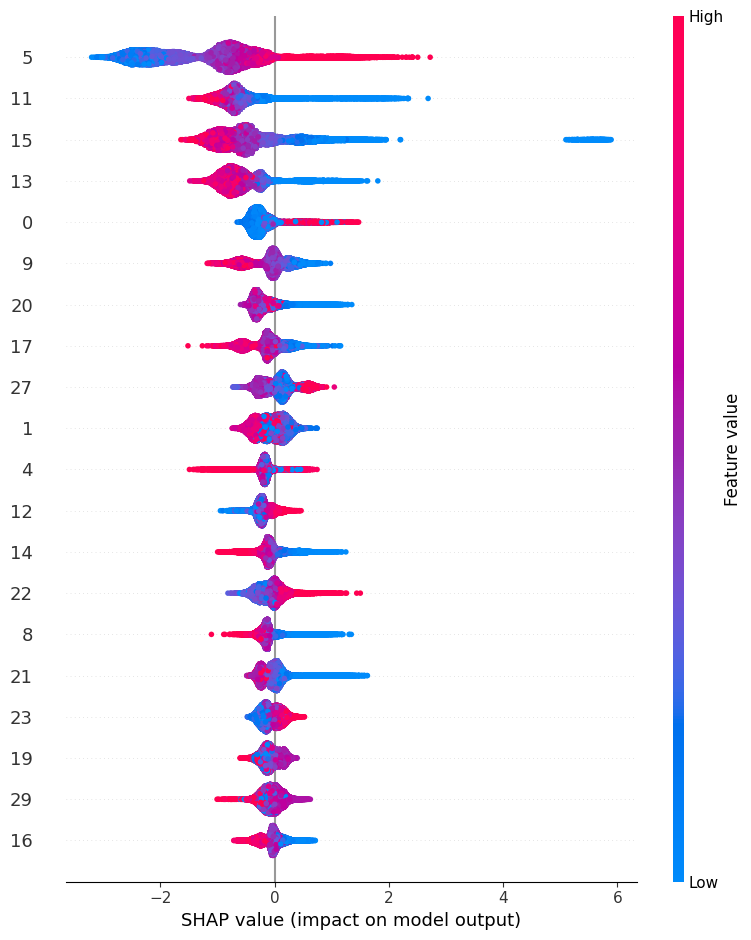

In [17]:
import shap

shap.summary_plot(shap_values, X_test_hybrid, plot_type="dot")


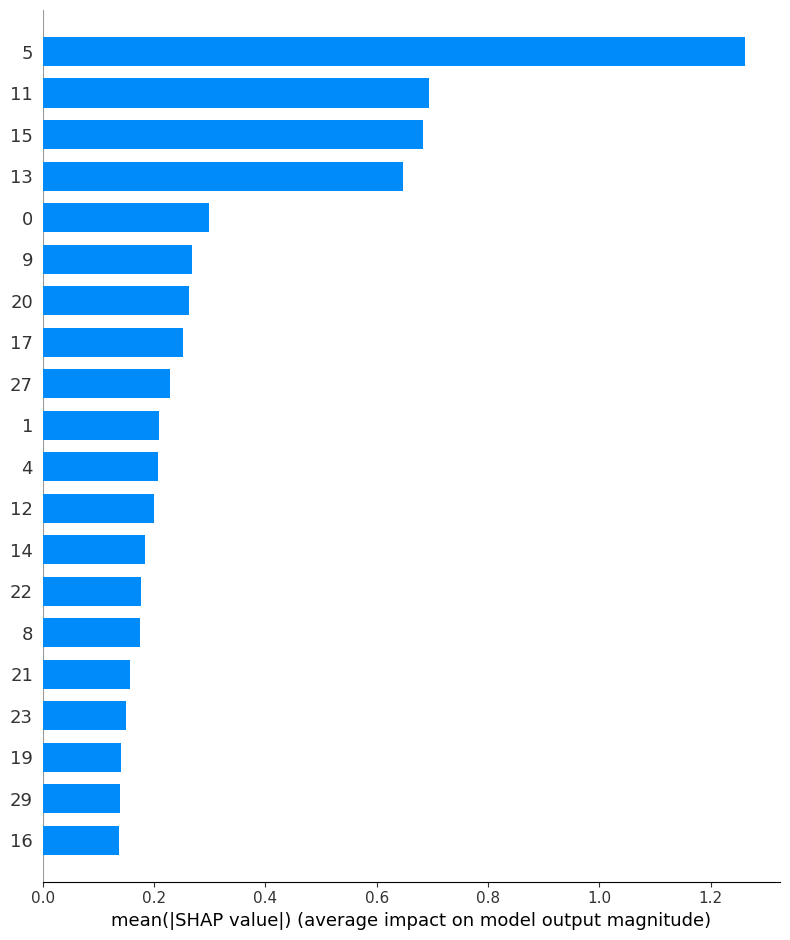

In [18]:
shap.summary_plot(shap_values, X_test_hybrid, plot_type="bar")


In [19]:
import numpy as np

fraud_idx = np.where(y_test.values == 1)[0][0]

shap.force_plot(
    explainer.expected_value,
    shap_values[fraud_idx],
    X_test_hybrid.iloc[fraud_idx],
    matplotlib=True
)


AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [20]:
import numpy as np

fraud_idx = np.where(y_test == 1)[0][0]


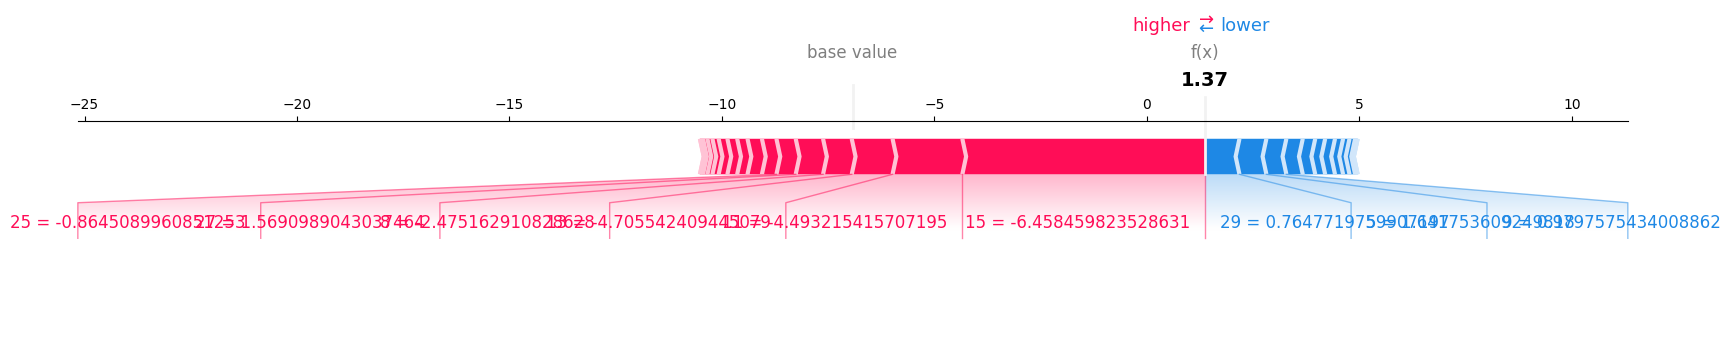

In [21]:
shap.force_plot(
    explainer.expected_value,
    shap_values[fraud_idx],
    X_test_hybrid.iloc[fraud_idx],
    matplotlib=True
)


In [22]:
# ---------- Cell: Install + imports ----------
!pip install optuna --quiet

import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import numpy as np

# If your data is in DataFrame:
# X = X_train_hybrid.values if you want pure numpy
X = X_train_hybrid
y = y_train

# Train/validation split (keep test set untouched)
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 21.1 MB/s eta 0:00:00


NameError: name 'X_train_hybrid' is not defined

In [23]:
from google.colab import files

files.download("rf_hybrid_final.joblib")
files.download("rf_hybrid_smote.joblib")
files.download("xgb_hybrid_final.json")
files.download("xgb_hybrid_smote.json")

files.download("X_test_hybrid.csv")
files.download("y_test.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>